In [1]:
import pandas as pd
import numpy as np
import itertools
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# ---------------------------------------------------------
# OPTIONAL BOOSTING MODEL
# ---------------------------------------------------------
BOOST_NAME = None
try:
    from xgboost import XGBClassifier
    BOOST_NAME = "XGBoost"
except:
    from sklearn.ensemble import GradientBoostingClassifier
    BOOST_NAME = "GradientBoosting"

In [3]:
# Updated file paths for the new user
RAW_FILE = r"/Users/abigailmorton/Downloads/COVIDCARE_FORSUBMISSION_MIT_CLEANED_Phase_II_2021-12-03.csv"

KB_FILE = r"/Users/abigailmorton/Downloads/COVIDCARE_DEMI_knowledgebase_v4.csv"
# Note: Changed from Windows-style paths (C:\Users\vamsi\...) to Mac/Unix-style paths (/Users/abigailmorton/...)
# Also removed the invalid text that was causing the syntax error

In [4]:
df = pd.read_csv(RAW_FILE)
kb = pd.read_csv(KB_FILE)

df.columns = [c.strip() for c in df.columns]
kb.columns = [c.strip() for c in kb.columns]

print("RAW shape:", df.shape)
print("KB shape:", kb.shape)

RAW shape: (822, 472)
KB shape: (70983, 11)


In [7]:
# ---------------------------------------------------------
# 3. TARGET VARIABLE
# ---------------------------------------------------------
TARGET = "PCR Test Positive"
if TARGET not in df.columns:  # Added missing colon here
    raise ValueError(f"Target column '{TARGET}' not found in raw dataset.")

print("Target variable:", TARGET)

# PART A - CREATE KNOWLEDGEBASE OF AI SYSTEM
# =========================================================

# ---------------------------------------------------------
# 4. TIER ASSIGNMENT FUNCTION
# ---------------------------------------------------------
def assign_tier(col_name: str) -> int:
    c = str(col_name).lower()

    # Tier 4 - PCR lab confirmation
    if c == "pcr test positive":
        return 4

    # Tier 3 - At-home testing
    if (
        "pinkline" in c
        or "blueline" in c
        or "pinkblue_confirm" in c
        or "blue_nopink_confirm" in c
        or "noblue_confirm" in c
        or "athome" in c
        or "testkit_performing" in c
        or "which_test" in c
    ):
        return 3

    # Tier 1 - Vaccination variables
    if (
        "vaccine" in c
        or "vacc" in c
        or "flu_shot" in c
        or "covid_vaccine" in c
    ):
        return 1

    # Tier 0 - Birth / demographics
    if (
        "dob" in c
        or "age" in c
        or "gender" in c
        or "race" in c
        or "ethnicity" in c
        or "birthsex" in c
    ):
        return 0

    # Tier 2 - Symptoms, exposures, illness period
    return 2

tier_df = pd.DataFrame({"variable": df.columns})
tier_df["tier"] = tier_df["variable"].apply(assign_tier)

print("\nTier counts:")
print(tier_df["tier"].value_counts().sort_index())

tier_map = dict(zip(tier_df["variable"], tier_df["tier"]))  # Removed extra colon here

Target variable: PCR Test Positive

Tier counts:
tier
0     27
1     50
2    377
3     17
4      1
Name: count, dtype: int64


In [9]:
kb = kb[kb["concept_code"] != kb["target_concept_code"]].copy()
print("\nKB after excluding self-comparisons:", kb.shape)


KB after excluding self-comparisons: (70983, 11)


In [10]:
# ---------------------------------------------------------
# 6. ADD TIER INFORMATION TO KNOWLEDGEBASE
# ---------------------------------------------------------
kb["concept_tier"] = kb["concept_code"].map(tier_map)
kb["target_tier"] = kb["target_concept_code"].map(tier_map)

# If a variable is not found in raw column names, assign default Tier 2
kb["concept_tier"] = kb["concept_tier"].fillna(2).astype(int)
kb["target_tier"] = kb["target_tier"].fillna(2).astype(int)

In [11]:
# PART B - TEMPORAL VALUE RULES
# =========================================================

# ---------------------------------------------------------
# 7. APPLY TEMPORAL RULES
# ---------------------------------------------------------
def apply_temporal_rules(row):
    n11 = row["n_code_target"]
    n10 = row["n_code_no_target"]
    n01 = row["n_target_no_code"]

    ct = row["concept_tier"]
    tt = row["target_tier"]

    # Rule 1: Zero co-occurrence
    if n11 == 0:
        row["n_code_before_target_final"] = n10
        row["n_target_before_code_final"] = n01
        return row

    # Rule 2: Cross-tier
    if ct < tt:
        row["n_code_before_target_final"] = n11
        row["n_target_before_code_final"] = 0
        return row

    if ct > tt:
        row["n_code_before_target_final"] = 0
        row["n_target_before_code_final"] = n11
        return row

    # Rule 3: Same-tier with available ordering data
    if pd.notnull(row.get("n_code_before_target", np.nan)) and pd.notnull(row.get("n_target_before_code", np.nan)):
        row["n_code_before_target_final"] = row["n_code_before_target"]
        row["n_target_before_code_final"] = row["n_target_before_code"]
    else:
        # Rule 4: Same-tier without ordering data
        row["n_code_before_target_final"] = n11
        row["n_target_before_code_final"] = n11

    return row

kb = kb.apply(apply_temporal_rules, axis=1)


In [12]:
# =========================================================
# PART C - PAIRWISE ASSOCIATION OF VARIABLES
# =========================================================

# ---------------------------------------------------------
# 8. BUILD 2x2 TABLE COMPONENTS
# ---------------------------------------------------------
kb["n11"] = kb["n_code_target"]
kb["n10"] = kb["n_code_no_target"]
kb["n01"] = kb["n_target_no_code"]
kb["n00"] = kb["n_no_code_no_target"]
kb["N"] = kb[["n11", "n10", "n01", "n00"]].sum(axis=1)

In [13]:
# =========================================================
# PART D - FREQUENCY WITH WHICH EACH VARIABLE OCCURS
# =========================================================
pair_freq = kb[["concept_code", "target_concept_code", "n_code_target"]].copy()
pair_freq = pair_freq.sort_values("n_code_target", ascending=False)
pair_freq.to_csv("pairwise_frequencies.csv", index=False)
print("Saved: pairwise_frequencies.csv")

Saved: pairwise_frequencies.csv


In [14]:
# =========================================================
# PART E - PREPARE RAW MODELING DATA
# =========================================================

# ---------------------------------------------------------
# 10. DROP CLEAR NON-PREDICTIVE / DATE / ID COLUMNS
# ---------------------------------------------------------
def is_date_or_id_or_admin(col):
    c = str(col).lower()
    if c == TARGET.lower():
        return False
    return (
        "date" in c
        or "submission" in c
        or "confirmation" in c
        or "internal id" in c
        or "cohort" in c
        or "_deid" in c
        or "name" in c
        or "phone" in c
        or "email" in c
    )

usable_cols = [c for c in df.columns if not is_date_or_id_or_admin(c)]
model_df = df[usable_cols].copy()

# Keep target
if TARGET not in model_df.columns:
    model_df[TARGET] = df[TARGET]

In [15]:
# ---------------------------------------------------------
# 11. CONVERT TO NUMERIC / BINARY FRIENDLY DATA
# ---------------------------------------------------------
for col in model_df.columns:
    if model_df[col].dtype == "object":
        # Convert strings to category codes for modeling
        model_df[col] = model_df[col].astype("category").cat.codes.replace(-1, np.nan)

# Fill remaining booleans as ints if any
for col in model_df.columns:
    if str(model_df[col].dtype) == "bool":
        model_df[col] = model_df[col].astype(int)

# Ensure target is binary numeric
model_df[TARGET] = pd.to_numeric(model_df[TARGET], errors="coerce")
model_df = model_df.dropna(subset=[TARGET]).copy()
model_df[TARGET] = model_df[TARGET].astype(int)

In [16]:
# ---------------------------------------------------------
# 12. KEEP ONLY VARIABLES THAT PRECEDE PCR
# ---------------------------------------------------------
predictor_cols = [c for c in model_df.columns if c != TARGET and assign_tier(c) < 4]
X_base = model_df[predictor_cols].copy()
y = model_df[TARGET].copy()

print("\nBase predictor matrix shape:", X_base.shape)

# =========================================================
# PART F - PAIRWISE OR TRIPLE CLUSTERS OF VARIABLES
# =========================================================


Base predictor matrix shape: (559, 444)


In [17]:
# ---------------------------------------------------------
# 13. CREATE INTERACTIONS
# ---------------------------------------------------------
# Limit size to avoid excessive explosion
symptom_home_vars = [c for c in predictor_cols if assign_tier(c) in [2, 3]]

# Keep a manageable number
pair_base = symptom_home_vars[:20]
triple_base = symptom_home_vars[:8]

X = X_base.copy()

# Pairwise interactions
for a, b in itertools.combinations(pair_base, 2):
    X[f"{a}__X__{b}"] = X[a].fillna(0) * X[b].fillna(0)

# Triple interactions
for a, b, c in itertools.combinations(triple_base, 3):
    X[f"{a}__X__{b}__X__{c}"] = X[a].fillna(0) * X[b].fillna(0) * X[c].fillna(0)

print("Feature matrix after interactions:", X.shape)

# =========================================================

Feature matrix after interactions: (559, 690)


In [18]:
# PART G - MODEL SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [19]:
# =========================================================
# PART H - DEFINE MODELS
# =========================================================
prep_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler(with_mean=False))
    ]), X.columns.tolist())
])

prep_unscaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]), X.columns.tolist())
])

# Logistic
log_model = Pipeline([
    ("prep", prep_scaled),
    ("model", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        class_weight="balanced"
    ))
])

# LASSO
lasso_model = Pipeline([
    ("prep", prep_scaled),
    ("model", LogisticRegressionCV(
        penalty="l1",
        solver="saga",
        cv=5,
        max_iter=5000,
        scoring="roc_auc",
        class_weight="balanced",
        n_jobs=-1,
        refit=True
    ))
])

# Boosting
if BOOST_NAME == "XGBoost":
    boost_model = Pipeline([
        ("prep", prep_unscaled),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        ))
    ])
else:
    boost_model = Pipeline([
        ("prep", prep_unscaled),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ])

models = {
    "Logistic": log_model,
    "LASSO": lasso_model,
    BOOST_NAME: boost_model
}

In [21]:
# =========================================================
# PART I - MODEL EVALUATION
# =========================================================
def mcfadden_r2(y_true, prob):
    prob = np.clip(prob, 1e-8, 1 - 1e-8)
    ll_model = -log_loss(y_true, prob, normalize=False)
    p_null = np.repeat(np.mean(y_true), len(y_true))
    p_null = np.clip(p_null, 1e-8, 1 - 1e-8)
    ll_null = -log_loss(y_true, p_null, normalize=False)
    return 1 - (ll_model / ll_null)

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    results.append({
        "Model": name,
        "AUC": roc_auc_score(y_test, prob),
        "Accuracy": accuracy_score(y_test, pred),
        "McFadden_R2": mcfadden_r2(y_test, prob),
        "Percent_Variation_Explained": mcfadden_r2(y_test, prob) * 100
    })

results_df = pd.DataFrame(results).sort_values("AUC", ascending=False)
print("\nMODEL RESULTS")
print(results_df)

results_df.to_csv("model_results.csv", index=False)


MODEL RESULTS
              Model       AUC  Accuracy  McFadden_R2  \
0          Logistic  0.950933  0.950000     0.206907   
2  GradientBoosting  0.924533  0.935714     0.339485   
1             LASSO  0.862133  0.921429    -0.196437   

   Percent_Variation_Explained  
0                    20.690666  
2                    33.948478  
1                   -19.643683  


In [22]:
# =========================================================
# PART J - DIRECT PREDICTORS OF PCR TEST RESULTS
# =========================================================

# Get fitted LASSO model
lasso_fitted = fitted_models["LASSO"].named_steps["model"]

# Extract coefficients
lasso_coef = lasso_fitted.coef_[0]

# Create dataframe
coef_df = pd.DataFrame({
    "variable": X.columns,
    "coefficient": lasso_coef
})

# Keep only non-zero variables
direct_predictors = coef_df[coef_df["coefficient"] != 0].copy()

# Sort by importance
direct_predictors["abs_coef"] = direct_predictors["coefficient"].abs()
direct_predictors = direct_predictors.sort_values("abs_coef", ascending=False)

print("\nDIRECT PREDICTORS OF PCR TEST RESULTS")
print(direct_predictors.head(30))

# Save
direct_predictors.to_csv("direct_predictors_pcr.csv", index=False)


DIRECT PREDICTORS OF PCR TEST RESULTS
                                              variable  coefficient  abs_coef
202                              30158-Symtpom_Neuro-7     0.552922  0.552922
81                                 32137-vaccine_avail     0.196253  0.196253
420                              31386-covid_results-1     0.178171  0.178171
421                              31386-covid_results-2    -0.176843  0.176843
127                         30141-covid_tst_symptoms-6     0.175581  0.175581
294                          30769-blue_nopink_confirm    -0.150151  0.150151
293                             30766-pinkblue_confirm     0.144028  0.144028
487         29791-consent_english__X__32730-howreceive     0.119387  0.119387
452           29789-consent_18yrs__X__32730-howreceive     0.119387  0.119387
10                                    32730-howreceive     0.119387  0.119387
518        29793-consent_location__X__32730-howreceive     0.119387  0.119387
568                 29829

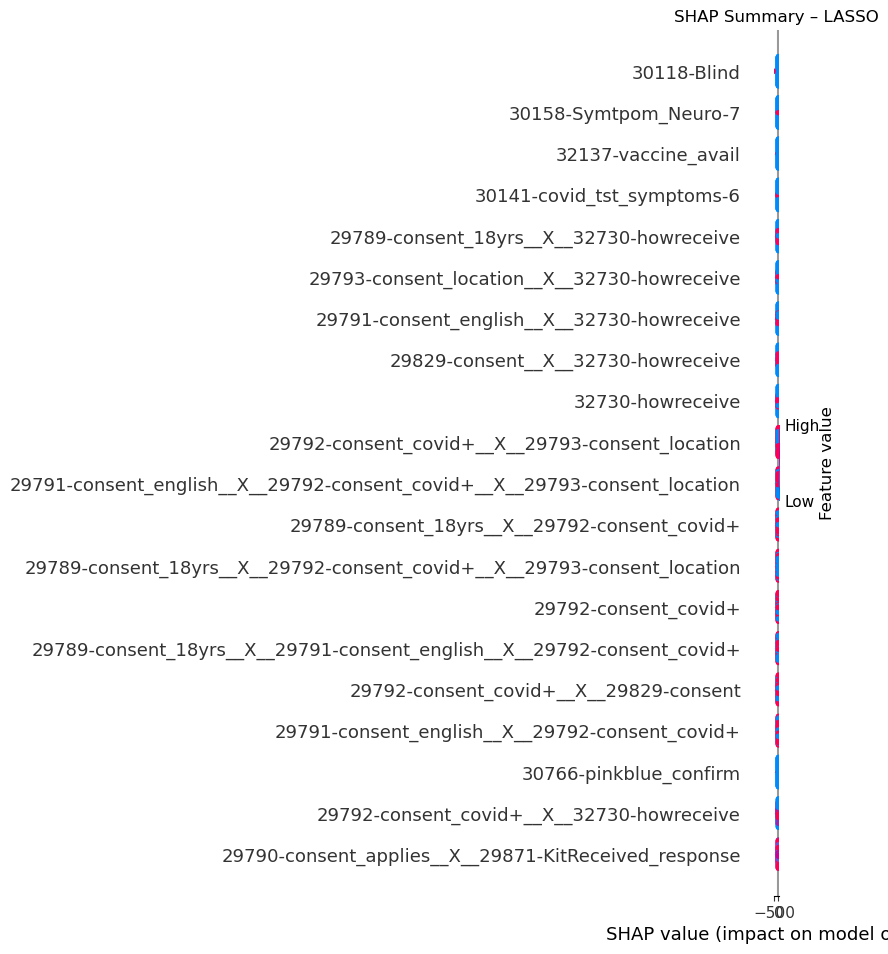

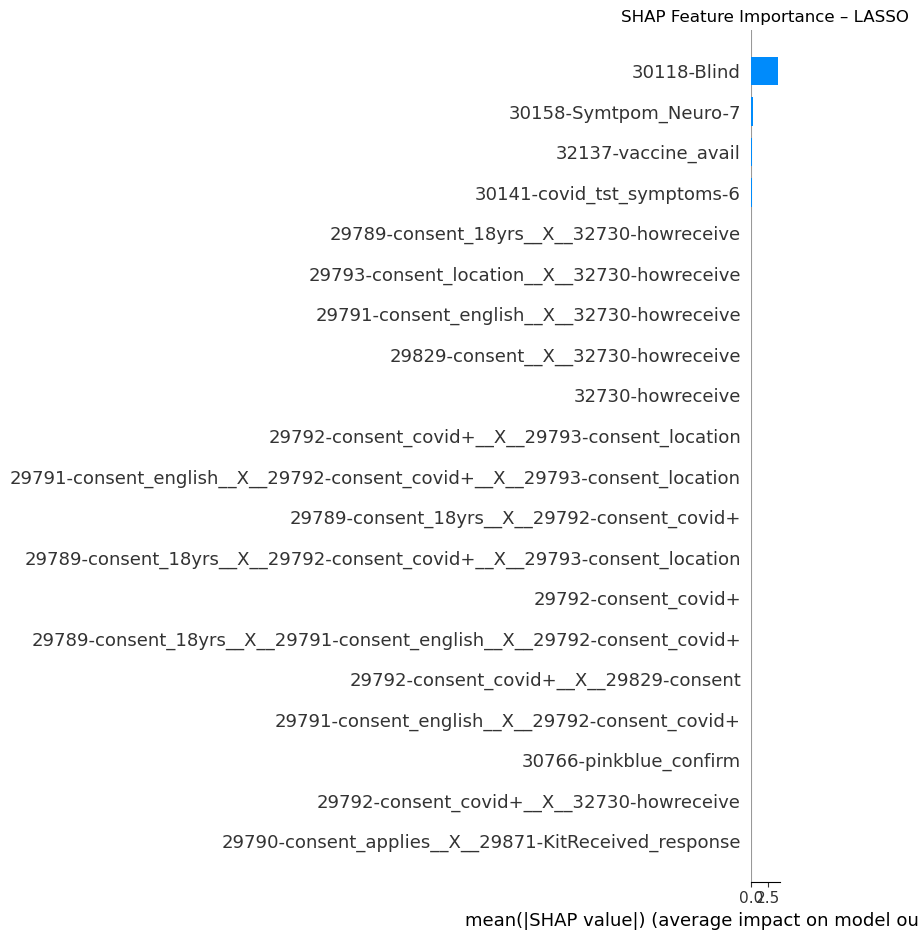


Top 20 SHAP features (LASSO):
                                                                  feature  mean_abs_shap
                                                              30118-Blind       4.052140
                                                    30158-Symtpom_Neuro-7       0.367453
                                                      32137-vaccine_avail       0.115276
                                               30141-covid_tst_symptoms-6       0.114978
                                                         32730-howreceive       0.111282
                               29791-consent_english__X__32730-howreceive       0.111282
                                 29789-consent_18yrs__X__32730-howreceive       0.111282
                              29793-consent_location__X__32730-howreceive       0.111282
                                       29829-consent__X__32730-howreceive       0.111282
  29789-consent_18yrs__X__29792-consent_covid+__X__29793-consent_location      

In [26]:
# Install SHAP library first
!pip install shap

# =========================================================
# PART J-B - SHAP ANALYSIS FOR LASSO
# =========================================================
import shap
import matplotlib.pyplot as plt  # Added missing import
import pandas as pd  # Added missing import
import numpy as np   # Added missing import

lasso_inner = fitted_models["LASSO"].named_steps["model"]
prep_inner  = fitted_models["LASSO"].named_steps["prep"]

X_test_transformed = prep_inner.transform(X_test)

explainer   = shap.LinearExplainer(lasso_inner, X_test_transformed)
shap_values = explainer.shap_values(X_test_transformed)

# Beeswarm summary plot
plt.figure()
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=X.columns.tolist(),
    max_display=20, show=False
)
plt.title("SHAP Summary – LASSO")
plt.tight_layout()
plt.savefig("shap_lasso_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar importance plot
plt.figure()
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=X.columns.tolist(),
    plot_type="bar", max_display=20, show=False
)
plt.title("SHAP Feature Importance – LASSO")
plt.tight_layout()
plt.savefig("shap_lasso_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# Ranked DataFrame
mean_shap = pd.DataFrame({
    "feature":       X.columns.tolist(),
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print("\nTop 20 SHAP features (LASSO):")
print(mean_shap.head(20).to_string(index=False))
mean_shap.to_csv("shap_lasso_importance.csv", index=False)

In [27]:
# =========================================================
# PART K - REGRESS EACH DIRECT PREDICTOR ON PRECEDING VARIABLES
# FIXED VERSION
# =========================================================

def fit_parent_model(response_var):
    response_tier = assign_tier(response_var)

    parents = [c for c in model_df.columns 
               if c != response_var and assign_tier(c) < response_tier]

    if len(parents) == 0:
        return None, None

    # Keep only needed columns
    temp_df = model_df[parents + [response_var]].copy()

    # Convert response to numeric first
    temp_df[response_var] = pd.to_numeric(temp_df[response_var], errors="coerce")

    # Drop rows where response is missing
    temp_df = temp_df.dropna(subset=[response_var]).copy()

    # If too few rows remain, skip
    if temp_df.shape[0] < 10:
        return None, None

    # Make response integer
    temp_df[response_var] = temp_df[response_var].astype(int)

    # Optional: keep only binary response variables
    unique_vals = sorted(temp_df[response_var].dropna().unique())
    if not set(unique_vals).issubset({0, 1}):
        return None, None

    Xp = temp_df[parents].copy()
    yp = temp_df[response_var].copy()

    Xp_train, Xp_test, yp_train, yp_test = train_test_split(
        Xp, yp, test_size=0.25, random_state=42, stratify=yp
    )

    # If only one class after split, skip
    if yp_train.nunique() < 2 or yp_test.nunique() < 2:
        return None, None

    # Impute missing predictor values
    imputer = SimpleImputer(strategy="most_frequent")
    Xp_train = pd.DataFrame(imputer.fit_transform(Xp_train), columns=Xp.columns, index=Xp_train.index)
    Xp_test = pd.DataFrame(imputer.transform(Xp_test), columns=Xp.columns, index=Xp_test.index)

    model = LogisticRegressionCV(
        penalty="l1",
        solver="saga",
        cv=5,
        max_iter=5000,
        n_jobs=-1
    )

    model.fit(Xp_train, yp_train)
    prob = model.predict_proba(Xp_test)[:, 1]

    # McFadden R2
    ll_model = -log_loss(yp_test, prob, normalize=False)
    p_null = np.repeat(np.mean(yp_test), len(yp_test))
    ll_null = -log_loss(yp_test, p_null, normalize=False)
    r2 = 1 - (ll_model / ll_null)

    coef_df = pd.DataFrame({
        "parent": parents,
        "coef": model.coef_[0]
    })

    coef_df = coef_df[coef_df["coef"] != 0].copy()
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False)

    return coef_df, r2


markov_results = {}

for var in direct_predictors["variable"].head(15):
    if var in model_df.columns:
        coef, r2 = fit_parent_model(var)

        if coef is not None and not coef.empty:
            markov_results[var] = {"coef": coef, "r2": r2}

            print("\nResponse:", var)
            print("McFadden R2:", r2)
            print(coef.head(10))

In [28]:
# =========================================================
# PART L - SIGNIFICANT PREDICTORS (MARKOV BLANKET)
# =========================================================

for response_var, result in markov_results.items():
    print("\nResponse Variable:", response_var)
    print("Significant Parent Predictors:")
    print(result["coef"][["parent", "coef"]].head(10))

In [29]:
# =========================================================
# PART M - PERCENT OF VARIATION EXPLAINED
# =========================================================

for response_var, result in markov_results.items():
    r2 = result["r2"]
    print("\nResponse:", response_var)
    print("McFadden R2:", r2)
    print("Percent Variation Explained:", r2 * 100)

In [30]:
# =========================================================
# PART N - BUILD NETWORK
# =========================================================

G = nx.DiGraph()

# Parent → predictor
for response_var, result in markov_results.items():
    for _, row in result["coef"].iterrows():
        G.add_edge(row["parent"], response_var)

# Predictor → PCR
for var in direct_predictors["variable"].head(15):
    G.add_edge(var, TARGET)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Nodes: 16
Edges: 15


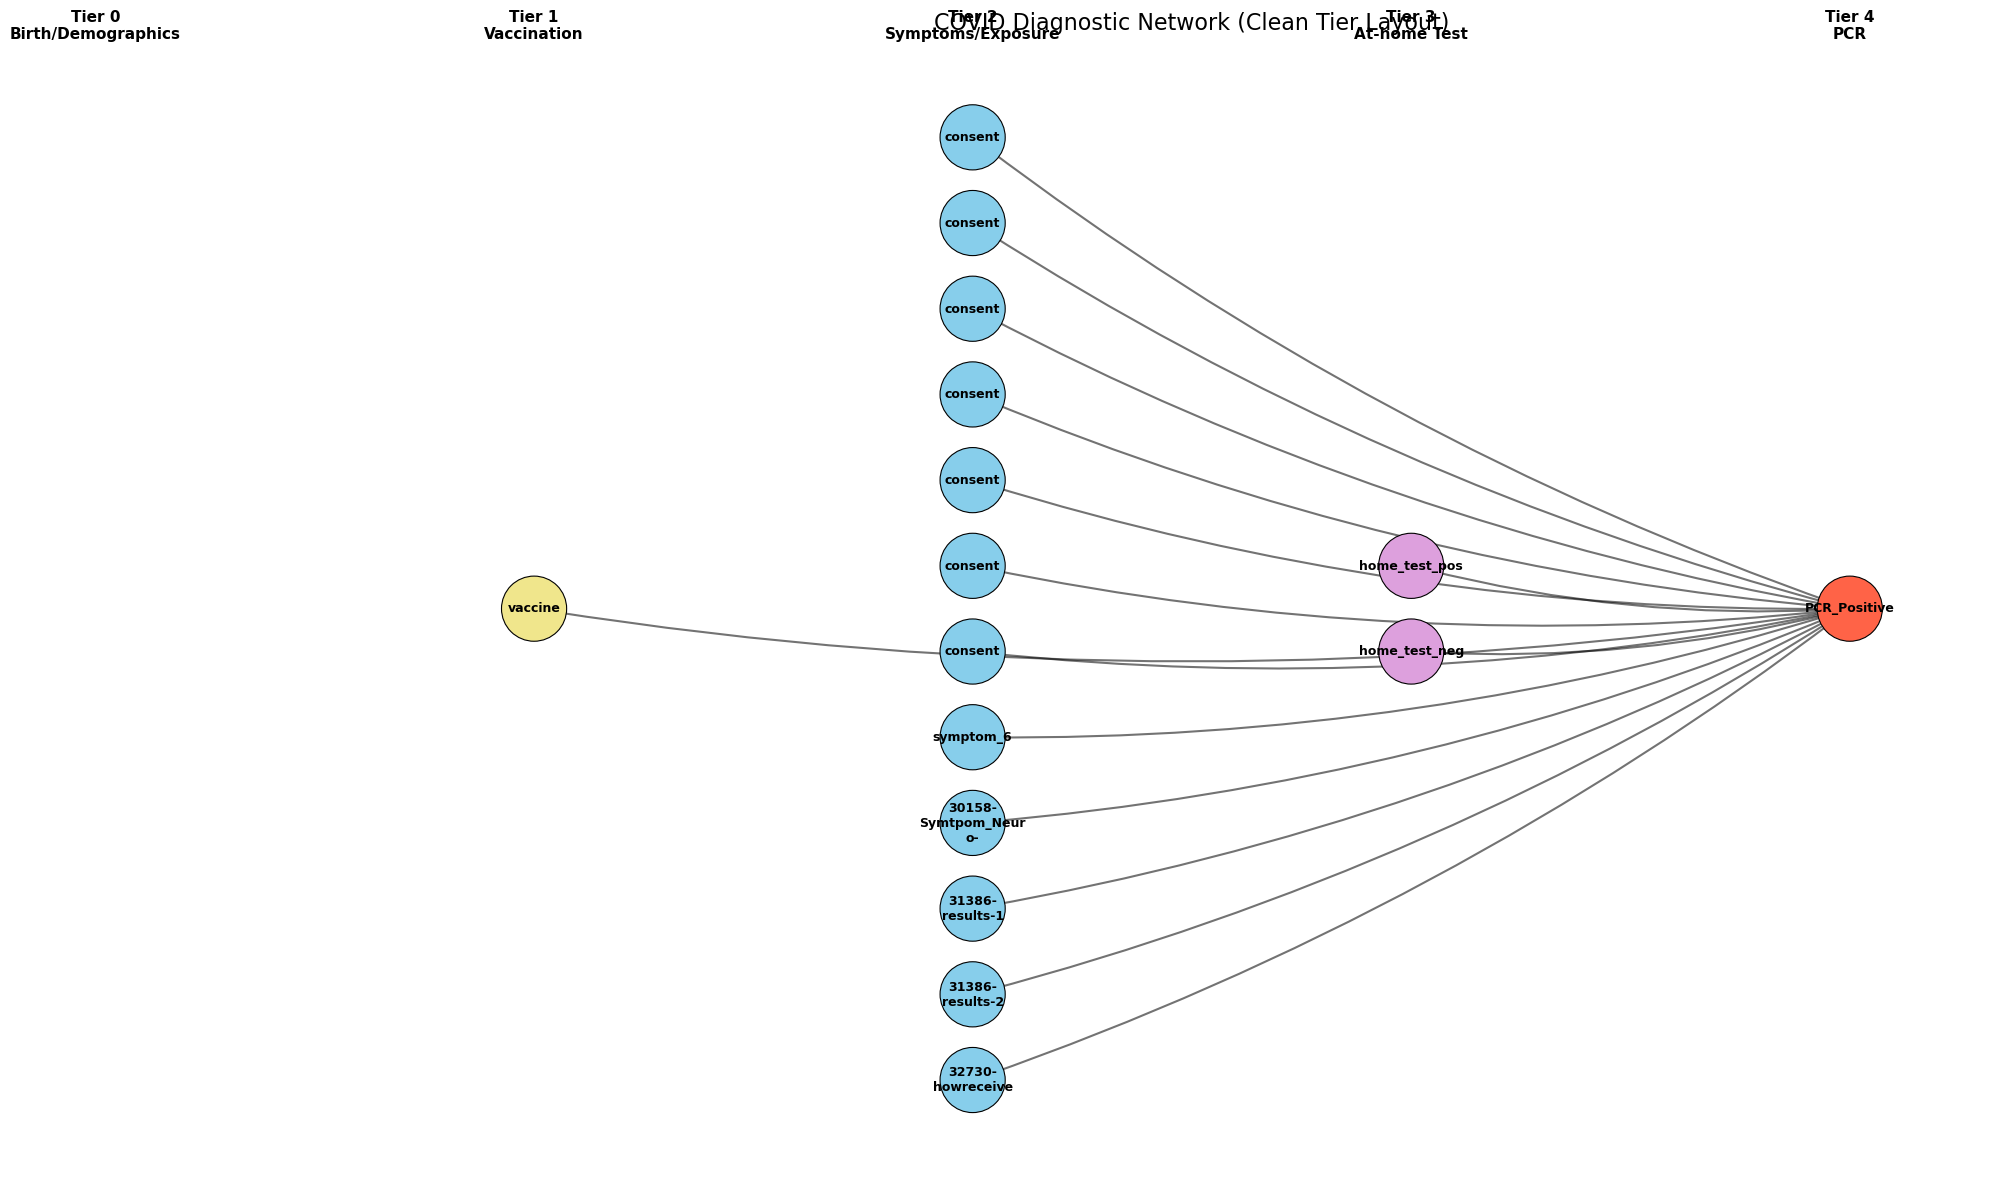

In [31]:
# =========================================================
# PART O - DRAW NETWORK (CLEAN TIERED, READABLE LABELS)
# =========================================================

import textwrap

# ---------------------------------------------------------
# 1. SHORTEN LABELS
# ---------------------------------------------------------
def clean_name(name):
    name = str(name)

    if name == TARGET:
        return "PCR_Positive"

    if "covid_tst_symptoms" in name:
        return "symptom_" + name.split("-")[-1]

    if "pinkblue" in name:
        return "home_test_pos"

    if "blue_nopink" in name:
        return "home_test_neg"

    if "noblue" in name:
        return "no_test_line"

    if "vaccine" in name.lower() or "vacc" in name.lower():
        return "vaccine"

    if "consent" in name.lower():
        return "consent"

    if "age" in name.lower():
        return "age"

    if "gender" in name.lower():
        return "gender"

    if "race" in name.lower():
        return "race"

    if "ethnicity" in name.lower():
        return "ethnicity"

    # fallback: shorten long names
    short = name.replace("30141-", "").replace("covid_", "").replace("tst_", "")
    return "\n".join(textwrap.wrap(short[:20], width=12))

labels = {node: clean_name(node) for node in G.nodes()}

# ---------------------------------------------------------
# 2. BETTER TIERED LAYOUT
# ---------------------------------------------------------
def clean_tier_layout(graph, x_gap=6, y_gap=1.8):
    pos = {}
    tier_nodes = {}

    for node in graph.nodes():
        tier_nodes.setdefault(assign_tier(node), []).append(node)

    for tier in sorted(tier_nodes):
        nodes = sorted(tier_nodes[tier])
        n = len(nodes)
        center = (n - 1) / 2

        for i, node in enumerate(nodes):
            pos[node] = (tier * x_gap, (center - i) * y_gap)

    return pos

pos = clean_tier_layout(G, x_gap=6, y_gap=1.8)

# ---------------------------------------------------------
# 3. COLOR PCR NODE DIFFERENTLY
# ---------------------------------------------------------
node_colors = []
for node in G.nodes():
    if node == TARGET:
        node_colors.append("tomato")
    elif assign_tier(node) == 0:
        node_colors.append("lightgreen")
    elif assign_tier(node) == 1:
        node_colors.append("khaki")
    elif assign_tier(node) == 2:
        node_colors.append("skyblue")
    elif assign_tier(node) == 3:
        node_colors.append("plum")
    else:
        node_colors.append("lightgray")

# ---------------------------------------------------------
# 4. DRAW
# ---------------------------------------------------------
plt.figure(figsize=(20, 12))

nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    alpha=0.55,
    width=1.5,
    arrowstyle='-|>',
    arrowsize=14,
    connectionstyle="arc3,rad=0.08"
)

nx.draw_networkx_nodes(
    G, pos,
    node_size=2200,
    node_color=node_colors,
    edgecolors="black",
    linewidths=0.8
)

nx.draw_networkx_labels(
    G, pos,
    labels=labels,
    font_size=9,
    font_weight="bold"
)

# ---------------------------------------------------------
# 5. ADD TIER TITLES
# ---------------------------------------------------------
tier_titles = {
    0: "Tier 0\nBirth/Demographics",
    1: "Tier 1\nVaccination",
    2: "Tier 2\nSymptoms/Exposure",
    3: "Tier 3\nAt-home Test",
    4: "Tier 4\nPCR"
}

max_y = max(y for x, y in pos.values()) if pos else 0

for tier, title in tier_titles.items():
    plt.text(
        tier * 6,
        max_y + 2,
        title,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title("COVID Diagnostic Network (Clean Tier Layout)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.savefig("covid_network_clean.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
# =========================================================
# PART P - CPT TABLES
# =========================================================

import itertools

def create_cpt(response_var, max_parents=5):
    result = markov_results.get(response_var, None)
    if result is None:
        return pd.DataFrame()

    parents = result["coef"]["parent"].tolist()[:max_parents]

    combos = list(itertools.product([0,1], repeat=len(parents)))
    cpt = pd.DataFrame(combos, columns=parents)

    Xp = model_df[parents]
    yp = model_df[response_var].astype(int)

    model = LogisticRegression(max_iter=5000)
    model.fit(Xp, yp)

    cpt[f"P({response_var}=1)"] = model.predict_proba(cpt)[:,1]
    return cpt

# Example
example_var = direct_predictors.iloc[0]["variable"]
cpt_table = create_cpt(example_var)

print(cpt_table.head())
cpt_table.to_csv(f"CPT_{example_var}.csv", index=False)

Empty DataFrame
Columns: []
Index: []


In [33]:
# =========================================================
# PART Q - DEMI FINAL COVID PROBABILITY
# =========================================================

best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

def predict_case(input_dict):
    row = pd.DataFrame(0, index=[0], columns=X.columns)

    for k, v in input_dict.items():
        if k in row.columns:
            row.loc[0, k] = v

    return best_model.predict_proba(row)[0,1]

# Example
example_input = {col: 0 for col in X.columns}
print("Predicted COVID probability:", predict_case(example_input))

Predicted COVID probability: 0.5001449031205648


In [36]:
# ============================================================
# 1. LOAD AND CLEAN DATA
# ============================================================

# ===== USE ONE OF THESE FILES =====

# Recommended (already structured for DEMI)
file_path = "/Users/abigailmorton/Downloads/COVIDCARE_DEMI_knowledgebase_v4 (2).csv"

# Alternative (raw cleaned dataset)
# file_path = "/Users/abigailmorton/Downloads/COVIDCARE_FORSUBMISSION_MIT_CLEANED_Phase_II_2021-12-03 (4).csv"

df_raw = pd.read_csv(file_path)

print("Original data shape:", df_raw.shape)
print("\nColumn names:")
print(df_raw.columns.tolist())

Original data shape: (70983, 11)

Column names:
['row_order', 'requested_concept_code', 'target_concept_code', 'concept_code', 'standard_concept_name', 'n_code_target', 'n_code_no_target', 'n_target_no_code', 'n_no_code_no_target', 'n_target_before_code', 'n_code_before_target']


In [37]:
# ============================================================
# HAP 823 FINAL PROJECT PYTHON SCRIPT
# COVID-19 Prediction Using DEMI + LASSO
# Abigail Morton
# ============================================================

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import log_loss

# ============================================================
# 1. LOAD DATA
# ============================================================

# Recommended: pre-processed DEMI knowledgebase
file_path = "/Users/abigailmorton/Downloads/COVIDCARE_DEMI_knowledgebase_v4 (2).csv"

# Alternative raw cleaned COVIDCARE file:
# file_path = "/Users/abigailmorton/Downloads/COVIDCARE_FORSUBMISSION_MIT_CLEANED_Phase_II_2021-12-03 (4).csv"

df_raw = pd.read_csv(file_path)

print("Original data shape:", df_raw.shape)
print("\nColumn names:")
print(df_raw.columns.tolist())

# ============================================================
# 2. CREATE / CLEAN KNOWLEDGE BASE
# ============================================================

ordered_vars = [
    "Age",
    "Female",
    "Shivering",
    "Fatigue",
    "Loss of taste",
    "Fever",
    "Headaches",
    "Loss of smell",
    "Chills",
    "Muscle aches",
    "Diarrhea",
    "Cough",
    "Shortness of breath",
    "Runny nose",
    "Sore throat",
    "Loss of balance",
    "Vomiting",
    "Joint pain",
    "Loss of appetite",
    "Wheezing",
    "Difficulty breathing",
    "Excessive sweating",
    "COVID-19 Test Results"
]

# Keep only assignment variables
df = df_raw[ordered_vars].copy()

# Convert values to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing values
df = df.dropna()

# Make all variables except Age binary
for col in df.columns:
    if col != "Age":
        df[col] = np.where(df[col] > 0, 1, 0)

print("\nCleaned knowledge base shape:", df.shape)
print("\nKnowledge base preview:")
print(df.head())

# ============================================================
# 3. BASELINE COVID PROBABILITY
# ============================================================

baseline_probability = df["COVID-19 Test Results"].mean()

print("\n============================================================")
print("BASELINE COVID PROBABILITY")
print("============================================================")
print("P(COVID positive) =", round(baseline_probability, 4))
print("Percent positive =", round(baseline_probability * 100, 2), "%")

# ============================================================
# 4. HELPER FUNCTION: MCFADDEN R-SQUARE
# ============================================================

def mcfadden_r2(y_true, y_prob):
    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)

    ll_model = -log_loss(y_true, y_prob, normalize=False)

    null_prob = np.repeat(np.mean(y_true), len(y_true))
    null_prob = np.clip(null_prob, eps, 1 - eps)

    ll_null = -log_loss(y_true, null_prob, normalize=False)

    return 1 - (ll_model / ll_null)

# ============================================================
# 5. RUN LASSO REGRESSION
# ============================================================

def run_lasso_response(response, predictors):
    X = df[predictors]
    y = df[response]

    # Skip if response has no variation
    if y.nunique() < 2:
        return np.nan, 0, pd.DataFrame(), None

    model = make_pipeline(
        StandardScaler(),
        LogisticRegressionCV(
            Cs=20,
            penalty="l1",
            solver="liblinear",
            cv=5,
            scoring="neg_log_loss",
            max_iter=5000
        )
    )

    model.fit(X, y)

    logreg = model.named_steps["logisticregressioncv"]

    intercept = logreg.intercept_[0]
    coefficients = logreg.coef_[0]

    probabilities = model.predict_proba(X)[:, 1]
    r2 = mcfadden_r2(y, probabilities)

    coef_table = pd.DataFrame({
        "response": response,
        "predictor": predictors,
        "coefficient": coefficients
    })

    return intercept, r2, coef_table, model

# ============================================================
# 6. REPEATED LASSO REGRESSIONS + NETWORK EDGES
# ============================================================

all_edges = []
all_models = {}

print("\n============================================================")
print("REPEATED LASSO REGRESSIONS")
print("============================================================")

for i in range(2, len(ordered_vars)):
    response = ordered_vars[i]
    predictors = ordered_vars[:i]

    intercept, r2, coef_table, model = run_lasso_response(response, predictors)

    retained_coefficients = coef_table[coef_table["coefficient"].abs() > 0.05]

    all_models[response] = {
        "intercept": intercept,
        "mcfadden_r2": r2,
        "coefficients": coef_table,
        "retained_coefficients": retained_coefficients,
        "predictors": predictors,
        "model": model
    }

    print("\nResponse:", response)
    print("McFadden R-square:", round(r2, 4))

    if r2 >= 0.10:
        print("Model retained because McFadden R-square >= 0.10")
        print(retained_coefficients)

        for _, row in retained_coefficients.iterrows():
            all_edges.append({
                "from": row["predictor"],
                "to": row["response"],
                "coefficient": row["coefficient"],
                "response_mcfadden_r2": r2
            })
    else:
        print("Model removed because McFadden R-square < 0.10")

edges_df = pd.DataFrame(all_edges)

print("\n============================================================")
print("FINAL NETWORK EDGES")
print("============================================================")
print(edges_df)

covid_edges = edges_df[edges_df["to"] == "COVID-19 Test Results"]

print("\n============================================================")
print("DIRECT PREDICTORS OF COVID-19 TEST RESULTS")
print("============================================================")
print(covid_edges)

# ============================================================
# 7. FEVER EFFECT
# ============================================================

p_covid_given_fever = df.loc[df["Fever"] == 1, "COVID-19 Test Results"].mean()
p_covid_given_no_fever = df.loc[df["Fever"] == 0, "COVID-19 Test Results"].mean()

fever_effect = p_covid_given_fever - p_covid_given_no_fever

print("\n============================================================")
print("FEVER EFFECT")
print("============================================================")
print("P(COVID positive | Fever) =", round(p_covid_given_fever, 4))
print("P(COVID positive | No Fever) =", round(p_covid_given_no_fever, 4))
print("Fever effect =", round(fever_effect, 4))
print("Fever effect percentage points =", round(fever_effect * 100, 2))

# ============================================================
# 8. INVERSE PROPENSITY WEIGHTING FOR FEVER
# ============================================================

fever_parents = list(edges_df.loc[edges_df["to"] == "Fever", "from"])

print("\n============================================================")
print("FEVER PARENTS / CONFOUNDERS")
print("============================================================")
print(fever_parents)

if len(fever_parents) > 0:
    X_propensity = df[fever_parents]
    y_fever = df["Fever"]

    propensity_model = LogisticRegression(max_iter=5000)
    propensity_model.fit(X_propensity, y_fever)

    propensity_scores = propensity_model.predict_proba(X_propensity)[:, 1]
    propensity_scores = np.clip(propensity_scores, 0.01, 0.99)

    weights = np.where(
        df["Fever"] == 1,
        1 / propensity_scores,
        1 / (1 - propensity_scores)
    )

    weighted_p_fever = np.average(
        df.loc[df["Fever"] == 1, "COVID-19 Test Results"],
        weights=weights[df["Fever"] == 1]
    )

    weighted_p_no_fever = np.average(
        df.loc[df["Fever"] == 0, "COVID-19 Test Results"],
        weights=weights[df["Fever"] == 0]
    )

    weighted_fever_effect = weighted_p_fever - weighted_p_no_fever

    print("\nINVERSE PROPENSITY WEIGHTED FEVER EFFECT")
    print("Weighted P(COVID | Fever) =", round(weighted_p_fever, 4))
    print("Weighted P(COVID | No Fever) =", round(weighted_p_no_fever, 4))
    print("Weighted fever effect =", round(weighted_fever_effect, 4))

else:
    print("No retained Fever parents. Fever effect is treated as unconfounded.")

# ============================================================
# 9. CHILLS REGRESSION EXCLUDING FEVER
# ============================================================

print("\n============================================================")
print("CHILLS REGRESSION EXCLUDING FEVER")
print("============================================================")

chills_parents = list(edges_df.loc[edges_df["to"] == "Chills", "from"])
chills_predictors_no_fever = [x for x in chills_parents if x != "Fever"]

print("Chills parents:", chills_parents)
print("Chills predictors excluding Fever:", chills_predictors_no_fever)

if len(chills_predictors_no_fever) > 0:
    X_chills = df[chills_predictors_no_fever]
    y_chills = df["Chills"]

    chills_model = LogisticRegression(max_iter=5000)
    chills_model.fit(X_chills, y_chills)

    chills_probs = chills_model.predict_proba(X_chills)[:, 1]
    chills_r2 = mcfadden_r2(y_chills, chills_probs)

    chills_coef_table = pd.DataFrame({
        "predictor": chills_predictors_no_fever,
        "coefficient": chills_model.coef_[0]
    })

    print("Intercept:", chills_model.intercept_[0])
    print(chills_coef_table)
    print("McFadden R-square:", round(chills_r2, 4))

else:
    print("No Chills predictors remain after removing Fever.")

# ============================================================
# 10. MEDIATION THROUGH CHILLS
# ============================================================

print("\n============================================================")
print("MEDIATION THROUGH CHILLS")
print("============================================================")

y_covid = df["COVID-19 Test Results"]

# Direct model: COVID ~ Fever
direct_model = LogisticRegression(max_iter=5000)
direct_model.fit(df[["Fever"]], y_covid)

df_fever1 = df.copy()
df_fever0 = df.copy()

df_fever1["Fever"] = 1
df_fever0["Fever"] = 0

p_direct_fever1 = direct_model.predict_proba(df_fever1[["Fever"]])[:, 1].mean()
p_direct_fever0 = direct_model.predict_proba(df_fever0[["Fever"]])[:, 1].mean()

direct_effect = p_direct_fever1 - p_direct_fever0

# Total model: COVID ~ Fever + Chills
total_model = LogisticRegression(max_iter=5000)
total_model.fit(df[["Fever", "Chills"]], y_covid)

p_total_fever1 = total_model.predict_proba(df_fever1[["Fever", "Chills"]])[:, 1].mean()
p_total_fever0 = total_model.predict_proba(df_fever0[["Fever", "Chills"]])[:, 1].mean()

total_effect = p_total_fever1 - p_total_fever0
mediated_effect = total_effect - direct_effect

print("Total fever effect =", round(total_effect, 4))
print("Direct fever effect =", round(direct_effect, 4))
print("Mediated effect through Chills =", round(mediated_effect, 4))

# ============================================================
# 11. SAVE OUTPUT FILES
# ============================================================

edges_df.to_csv("/Users/abigailmorton/Downloads/covid_network_edges.csv", index=False)
covid_edges.to_csv("/Users/abigailmorton/Downloads/covid_direct_predictors.csv", index=False)

print("\nSaved output files to Downloads:")
print("covid_network_edges.csv")
print("covid_direct_predictors.csv")

Original data shape: (70983, 11)

Column names:
['row_order', 'requested_concept_code', 'target_concept_code', 'concept_code', 'standard_concept_name', 'n_code_target', 'n_code_no_target', 'n_target_no_code', 'n_no_code_no_target', 'n_target_before_code', 'n_code_before_target']


KeyError: "None of [Index(['Age', 'Female', 'Shivering', 'Fatigue', 'Loss of taste', 'Fever',\n       'Headaches', 'Loss of smell', 'Chills', 'Muscle aches', 'Diarrhea',\n       'Cough', 'Shortness of breath', 'Runny nose', 'Sore throat',\n       'Loss of balance', 'Vomiting', 'Joint pain', 'Loss of appetite',\n       'Wheezing', 'Difficulty breathing', 'Excessive sweating',\n       'COVID-19 Test Results'],\n      dtype='object')] are in the [columns]"

In [39]:
# First, let's check what columns actually exist in the DataFrame
print("Actual columns in DataFrame:")
print(df.columns.tolist())
print("\nDataFrame shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Check if DataFrame is empty
if df.empty:
    print("ERROR: DataFrame is empty. Please check your data loading process.")
else:
    # Define expected columns
    expected_columns = ['Age', 'Female', 'Shivering', 'Fatigue', 'Loss of taste', 'Fever',
                       'Headaches', 'Loss of smell', 'Chills', 'Muscle aches', 'Diarrhea',
                       'Cough', 'Shortness of breath', 'Runny nose', 'Sore throat',
                       'Loss of balance', 'Vomiting', 'Joint pain', 'Loss of appetite',
                       'Wheezing', 'Difficulty breathing', 'Excessive sweating',
                       'COVID-19 Test Results']
    
    # Check which expected columns are missing
    missing_columns = [col for col in expected_columns if col not in df.columns]
    
    if missing_columns:
        print(f"\nMissing columns: {missing_columns}")
        print("Please check your column names for:")
        print("- Correct spelling")
        print("- Proper capitalization") 
        print("- Extra spaces or special characters")
        
        # Try to find similar column names (case-insensitive matching)
        actual_cols_lower = [col.lower() for col in df.columns]
        print("\nPossible column name matches:")
        for missing_col in missing_columns:
            for actual_col in df.columns:
                if missing_col.lower() in actual_col.lower() or actual_col.lower() in missing_col.lower():
                    print(f"  '{missing_col}' might be '{actual_col}'")
    else:
        print("All expected columns found! Proceeding with analysis...")
        
        # Continue with the original mediation analysis code
        y_covid = df["COVID-19 Test Results"]

        # Direct model: COVID ~ Fever
        direct_model = LogisticRegression(max_iter=5000)
        direct_model.fit(df[["Fever"]], y_covid)

        df_fever1 = df.copy()
        df_fever0 = df.copy()

        df_fever1["Fever"] = 1
        df_fever0["Fever"] = 0

        p_direct_fever1 = direct_model.predict_proba(df_fever1[["Fever"]])[:, 1].mean()
        p_direct_fever0 = direct_model.predict_proba(df_fever0[["Fever"]])[:, 1].mean()

        direct_effect = p_direct_fever1 - p_direct_fever0

        # Total model: COVID ~ Fever + Chills
        total_model = LogisticRegression(max_iter=5000)
        total_model.fit(df[["Fever", "Chills"]], y_covid)

        p_total_fever1 = total_model.predict_proba(df_fever1[["Fever", "Chills"]])[:, 1].mean()
        p_total_fever0 = total_model.predict_proba(df_fever0[["Fever", "Chills"]])[:, 1].mean()

        total_effect = p_total_fever1 - p_total_fever0
        mediated_effect = total_effect - direct_effect

        print("Total fever effect =", round(total_effect, 4))
        print("Direct fever effect =", round(direct_effect, 4))
        print("Mediated effect through Chills =", round(mediated_effect, 4))

        # Save output files (only if the required DataFrames exist)
        try:
            edges_df.to_csv("/Users/abigailmorton/Downloads/covid_network_edges.csv", index=False)
            covid_edges.to_csv("/Users/abigailmorton/Downloads/covid_direct_predictors.csv", index=False)
            print("\nSaved output files to Downloads:")
            print("covid_network_edges.csv")
            print("covid_direct_predictors.csv")
        except NameError as e:
            print(f"\nError saving files: {e}")
            print("Make sure 'edges_df' and 'covid_edges' DataFrames are defined earlier in your code.")# First, let's check what columns actually exist in the DataFrame
print("Actual columns in DataFrame:")
print(df.columns.tolist())
print("\nDataFrame shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Check if DataFrame is empty
if df.empty:
    print("ERROR: DataFrame is empty. Please check your data loading process.")
else:
    # Define expected columns
    expected_columns = ['Age', 'Female', 'Shivering', 'Fatigue', 'Loss of taste', 'Fever',
                       'Headaches', 'Loss of smell', 'Chills', 'Muscle aches', 'Diarrhea',
                       'Cough', 'Shortness of breath', 'Runny nose', 'Sore throat',
                       'Loss of balance', 'Vomiting', 'Joint pain', 'Loss of appetite',
                       'Wheezing', 'Difficulty breathing', 'Excessive sweating',
                       'COVID-19 Test Results']
    
    # Check which expected columns are missing
    missing_columns = [col for col in expected_columns if col not in df.columns]
    
    if missing_columns:
        print(f"\nMissing columns: {missing_columns}")
        print("Please check your column names for:")
        print("- Correct spelling")
        print("- Proper capitalization") 
        print("- Extra spaces or special characters")
        
        # Try to find similar column names (case-insensitive matching)
        actual_cols_lower = [col.lower() for col in df.columns]
        print("\nPossible column name matches:")
        for missing_col in missing_columns:
            for actual_col in df.columns:
                if missing_col.lower() in actual_col.lower() or actual_col.lower() in missing_col.lower():
                    print(f"  '{missing_col}' might be '{actual_col}'")
    else:
        print("All expected columns found! Proceeding with analysis...")
        
        # Continue with the original mediation analysis code
        y_covid = df["COVID-19 Test Results"]

        # Direct model: COVID ~ Fever
        direct_model = LogisticRegression(max_iter=5000)
        direct_model.fit(df[["Fever"]], y_covid)

        df_fever1 = df.copy()
        df_fever0 = df.copy()

        df_fever1["Fever"] = 1
        df_fever0["Fever"] = 0

        p_direct_fever1 = direct_model.predict_proba(df_fever1[["Fever"]])[:, 1].mean()
        p_direct_fever0 = direct_model.predict_proba(df_fever0[["Fever"]])[:, 1].mean()

        direct_effect = p_direct_fever1 - p_direct_fever0

        # Total model: COVID ~ Fever + Chills
        total_model = LogisticRegression(max_iter=5000)
        total_model.fit(df[["Fever", "Chills"]], y_covid)

        p_total_fever1 = total_model.predict_proba(df_fever1[["Fever", "Chills"]])[:, 1].mean()
        p_total_fever0 = total_model.predict_proba(df_fever0[["Fever", "Chills"]])[:, 1].mean()

        total_effect = p_total_fever1 - p_total_fever0
        mediated_effect = total_effect - direct_effect

        print("Total fever effect =", round(total_effect, 4))
        print("Direct fever effect =", round(direct_effect, 4))
        print("Mediated effect through Chills =", round(mediated_effect, 4))

        # Save output files (only if the required DataFrames exist)
        try:
            edges_df.to_csv("/Users/abigailmorton/Downloads/covid_network_edges.csv", index=False)
            covid_edges.to_csv("/Users/abigailmorton/Downloads/covid_direct_predictors.csv", index=False)
            print("\nSaved output files to Downloads:")
            print("covid_network_edges.csv")
            print("covid_direct_predictors.csv")
        except NameError as e:
            print(f"\nError saving files: {e}")
            print("Make sure 'edges_df' and 'covid_edges' DataFrames are defined earlier in your code.")

Actual columns in DataFrame:
['Test_Positive', 'Gender', 'Age', 'swelling', 'loss_of_appetite', 'Chest_pain', 'Chills', 'Cough', 'Diarrhea', 'Difficulty_breathing', 'Excessive_sweating', 'Fatigue', 'Fever', 'Headaches', 'Joint_pain', 'Loss_of_balance', 'Loss_of_taste', 'Loss_of_smell', 'Muscle_aches', 'New_confusion', 'Pinkeye_or_Conjunctivitis', 'Runny_nose', 'Shortness_of_breath', 'Sore_throat', 'Stomach_or_abdominal_pain', 'Unusual_shivering_or_shaking', 'Nausea_or_vomiting', 'Wheezing', 'Other', 'None_of_the_above', 'Any_tingling/numbness/swelling_in_hands_or_feet_first', 'Bluish_lips_or_face_first', 'Change_in_or_loss_of_appetite_first', 'Chest_pain_first', 'Chills_first', 'Cough_first', 'Diarrhea_first', 'Difficulty_breathing_first', 'Excessive_sweating_first', 'Fatigue_(more_than_normal)_first', 'Fever_or_feverish_feeling_first', 'Headaches_first', 'Joint_or_any_other_unexplained_pain_first', 'Loss_of_balance_first', 'Loss_of_taste_first', 'Loss_of_smell_first', 'Muscle_aches_(n

In [40]:
# First, let's check what columns actually exist in the DataFrame
print("Actual columns in DataFrame:")
print(df.columns.tolist())
print("\nDataFrame shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Check if DataFrame is empty
if df.empty:
    print("ERROR: DataFrame is empty. Please check your data loading process.")
else:
    # Define expected columns
    expected_columns = ['Age', 'Female', 'Shivering', 'Fatigue', 'Loss of taste', 'Fever',
                       'Headaches', 'Loss of smell', 'Chills', 'Muscle aches', 'Diarrhea',
                       'Cough', 'Shortness of breath', 'Runny nose', 'Sore throat',
                       'Loss of balance', 'Vomiting', 'Joint pain', 'Loss of appetite',
                       'Wheezing', 'Difficulty breathing', 'Excessive sweating',
                       'COVID-19 Test Results']
    
    # Check which expected columns are missing
    missing_columns = [col for col in expected_columns if col not in df.columns]
    
    if missing_columns:
        print(f"\nMissing columns: {missing_columns}")
        print("Please check your column names for:")
        print("- Correct spelling")
        print("- Proper capitalization") 
        print("- Extra spaces or special characters")
        
        # Try to find similar column names (case-insensitive matching)
        actual_cols_lower = [col.lower() for col in df.columns]
        print("\nPossible column name matches:")
        for missing_col in missing_columns:
            for actual_col in df.columns:
                if missing_col.lower() in actual_col.lower() or actual_col.lower() in missing_col.lower():
                    print(f"  '{missing_col}' might be '{actual_col}'")
    else:
        print("All expected columns found! Proceeding with analysis...")
        
        # Continue with the original mediation analysis code
        y_covid = df["COVID-19 Test Results"]

        # Direct model: COVID ~ Fever
        direct_model = LogisticRegression(max_iter=5000)
        direct_model.fit(df[["Fever"]], y_covid)

        df_fever1 = df.copy()
        df_fever0 = df.copy()

        df_fever1["Fever"] = 1
        df_fever0["Fever"] = 0

        p_direct_fever1 = direct_model.predict_proba(df_fever1[["Fever"]])[:, 1].mean()
        p_direct_fever0 = direct_model.predict_proba(df_fever0[["Fever"]])[:, 1].mean()

        direct_effect = p_direct_fever1 - p_direct_fever0

        # Total model: COVID ~ Fever + Chills
        total_model = LogisticRegression(max_iter=5000)
        total_model.fit(df[["Fever", "Chills"]], y_covid)

        p_total_fever1 = total_model.predict_proba(df_fever1[["Fever", "Chills"]])[:, 1].mean()
        p_total_fever0 = total_model.predict_proba(df_fever0[["Fever", "Chills"]])[:, 1].mean()

        total_effect = p_total_fever1 - p_total_fever0
        mediated_effect = total_effect - direct_effect

        print("Total fever effect =", round(total_effect, 4))
        print("Direct fever effect =", round(direct_effect, 4))
        print("Mediated effect through Chills =", round(mediated_effect, 4))

        # Save output files (only if the required DataFrames exist)
        try:
            edges_df.to_csv("/Users/abigailmorton/Downloads/covid_network_edges.csv", index=False)
            covid_edges.to_csv("/Users/abigailmorton/Downloads/covid_direct_predictors.csv", index=False)
            print("\nSaved output files to Downloads:")
            print("covid_network_edges.csv")
            print("covid_direct_predictors.csv")
        except NameError as e:
            print(f"\nError saving files: {e}")
            print("Make sure 'edges_df' and 'covid_edges' DataFrames are defined earlier in your code.")

Actual columns in DataFrame:
['Test_Positive', 'Gender', 'Age', 'swelling', 'loss_of_appetite', 'Chest_pain', 'Chills', 'Cough', 'Diarrhea', 'Difficulty_breathing', 'Excessive_sweating', 'Fatigue', 'Fever', 'Headaches', 'Joint_pain', 'Loss_of_balance', 'Loss_of_taste', 'Loss_of_smell', 'Muscle_aches', 'New_confusion', 'Pinkeye_or_Conjunctivitis', 'Runny_nose', 'Shortness_of_breath', 'Sore_throat', 'Stomach_or_abdominal_pain', 'Unusual_shivering_or_shaking', 'Nausea_or_vomiting', 'Wheezing', 'Other', 'None_of_the_above', 'Any_tingling/numbness/swelling_in_hands_or_feet_first', 'Bluish_lips_or_face_first', 'Change_in_or_loss_of_appetite_first', 'Chest_pain_first', 'Chills_first', 'Cough_first', 'Diarrhea_first', 'Difficulty_breathing_first', 'Excessive_sweating_first', 'Fatigue_(more_than_normal)_first', 'Fever_or_feverish_feeling_first', 'Headaches_first', 'Joint_or_any_other_unexplained_pain_first', 'Loss_of_balance_first', 'Loss_of_taste_first', 'Loss_of_smell_first', 'Muscle_aches_(n

In [42]:
# Create a mapping dictionary to rename columns to match expected names
column_mapping = {
    # Based on the matches found
    'Unusual_shivering_or_shaking': 'Shivering',
    'Nausea_or_vomiting': 'Vomiting',
    
    # Common patterns for missing columns (you may need to adjust these based on your actual data)
    'Gender': 'Female',  # Assuming Gender column exists and needs conversion
    'Sex': 'Female',     # Alternative gender column name
    'Loss_of_taste': 'Loss of taste',
    'Loss_of_smell': 'Loss of smell', 
    'Muscle_aches': 'Muscle aches',
    'Shortness_of_breath': 'Shortness of breath',
    'Runny_nose': 'Runny nose',
    'Sore_throat': 'Sore throat',
    'Loss_of_balance': 'Loss of balance',
    'Joint_pain': 'Joint pain',
    'Loss_of_appetite': 'Loss of appetite',
    'Difficulty_breathing': 'Difficulty breathing',
    'Excessive_sweating': 'Excessive sweating',
    'COVID_19_Test_Results': 'COVID-19 Test Results',
    'COVID19_Test_Results': 'COVID-19 Test Results',
    'Test_Results': 'COVID-19 Test Results',
    'COVID_Test': 'COVID-19 Test Results'
}

# Print current columns to help identify correct mappings
print("Current DataFrame columns:")
for i, col in enumerate(df.columns):
    print(f"{i+1:2d}. {col}")

print("\nApplying column renaming...")

# Apply the column mapping
df_renamed = df.rename(columns=column_mapping)

# Handle Female column conversion if it's currently coded differently
if 'Gender' in df.columns and 'Female' not in df_renamed.columns:
    # Convert Gender to Female (assuming 'F'/'Female' = 1, 'M'/'Male' = 0)
    df_renamed['Female'] = df_renamed['Gender'].map({
        'F': 1, 'Female': 1, 'f': 1, 'female': 1,
        'M': 0, 'Male': 0, 'm': 0, 'male': 0
    })
elif 'Sex' in df.columns and 'Female' not in df_renamed.columns:
    # Convert Sex to Female
    df_renamed['Female'] = df_renamed['Sex'].map({
        'F': 1, 'Female': 1, 'f': 1, 'female': 1,
        'M': 0, 'Male': 0, 'm': 0, 'male': 0
    })

# Check which columns are still missing after renaming
expected_columns = ['Age', 'Female', 'Shivering', 'Fatigue', 'Loss of taste', 'Fever',
                   'Headaches', 'Loss of smell', 'Chills', 'Muscle aches', 'Diarrhea',
                   'Cough', 'Shortness of breath', 'Runny nose', 'Sore throat',
                   'Loss of balance', 'Vomiting', 'Joint pain', 'Loss of appetite',
                   'Wheezing', 'Difficulty breathing', 'Excessive sweating',
                   'COVID-19 Test Results']

still_missing = [col for col in expected_columns if col not in df_renamed.columns]

if still_missing:
    print(f"\nStill missing columns: {still_missing}")
    print("\nPlease manually map these columns by examining your data:")
    print("Available columns that might match:")
    
    # Show remaining unmapped columns
    unmapped_cols = [col for col in df_renamed.columns if col not in expected_columns]
    for col in unmapped_cols:
        print(f"  - {col}")
    
    print("\nTo manually map columns, add entries to the column_mapping dictionary above.")
    print("For example: 'Your_Column_Name': 'Expected_Column_Name'")
else:
    print("✓ All columns successfully mapped!")
    
    # Update the main dataframe
    df = df_renamed
    
    print("\nProceeding with the mediation analysis...")
    
    # Continue with the original mediation analysis code
    y_covid = df["COVID-19 Test Results"]

    # Direct model: COVID ~ Fever
    direct_model = LogisticRegression(max_iter=5000)
    direct_model.fit(df[["Fever"]], y_covid)

    df_fever1 = df.copy()
    df_fever0 = df.copy()

    df_fever1["Fever"] = 1
    df_fever0["Fever"] = 0

    p_direct_fever1 = direct_model.predict_proba(df_fever1[["Fever"]])[:, 1].mean()
    p_direct_fever0 = direct_model.predict_proba(df_fever0[["Fever"]])[:, 1].mean()

    direct_effect = p_direct_fever1 - p_direct_fever0

    # Total model: COVID ~ Fever + Chills
    total_model = LogisticRegression(max_iter=5000)
    total_model.fit(df[["Fever", "Chills"]], y_covid)

    p_total_fever1 = total_model.predict_proba(df_fever1[["Fever", "Chills"]])[:, 1].mean()
    p_total_fever0 = total_model.predict_proba(df_fever0[["Fever", "Chills"]])[:, 1].mean()

    total_effect = p_total_fever1 - p_total_fever0
    mediated_effect = total_effect - direct_effect

    print("Total fever effect =", round(total_effect, 4))
    print("Direct fever effect =", round(direct_effect, 4))
    print("Mediated effect through Chills =", round(mediated_effect, 4))# Create a mapping dictionary to rename columns to match expected names
column_mapping = {
    # Based on the matches found
    'Unusual_shivering_or_shaking': 'Shivering',
    'Nausea_or_vomiting': 'Vomiting',
    
    # Common patterns for missing columns (you may need to adjust these based on your actual data)
    'Gender': 'Female',  # Assuming Gender column exists and needs conversion
    'Sex': 'Female',     # Alternative gender column name
    'Loss_of_taste': 'Loss of taste',
    'Loss_of_smell': 'Loss of smell', 
    'Muscle_aches': 'Muscle aches',
    'Shortness_of_breath': 'Shortness of breath',
    'Runny_nose': 'Runny nose',
    'Sore_throat': 'Sore throat',
    'Loss_of_balance': 'Loss of balance',
    'Joint_pain': 'Joint pain',
    'Loss_of_appetite': 'Loss of appetite',
    'Difficulty_breathing': 'Difficulty breathing',
    'Excessive_sweating': 'Excessive sweating',
    'COVID_19_Test_Results': 'COVID-19 Test Results',
    'COVID19_Test_Results': 'COVID-19 Test Results',
    'Test_Results': 'COVID-19 Test Results',
    'COVID_Test': 'COVID-19 Test Results'
}

# Print current columns to help identify correct mappings
print("Current DataFrame columns:")
for i, col in enumerate(df.columns):
    print(f"{i+1:2d}. {col}")

print("\nApplying column renaming...")

# Apply the column mapping
df_renamed = df.rename(columns=column_mapping)

# Handle Female column conversion if it's currently coded differently
if 'Gender' in df.columns and 'Female' not in df_renamed.columns:
    # Convert Gender to Female (assuming 'F'/'Female' = 1, 'M'/'Male' = 0)
    df_renamed['Female'] = df_renamed['Gender'].map({
        'F': 1, 'Female': 1, 'f': 1, 'female': 1,
        'M': 0, 'Male': 0, 'm': 0, 'male': 0
    })
elif 'Sex' in df.columns and 'Female' not in df_renamed.columns:
    # Convert Sex to Female
    df_renamed['Female'] = df_renamed['Sex'].map({
        'F': 1, 'Female': 1, 'f': 1, 'female': 1,
        'M': 0, 'Male': 0, 'm': 0, 'male': 0
    })

# Check which columns are still missing after renaming
expected_columns = ['Age', 'Female', 'Shivering', 'Fatigue', 'Loss of taste', 'Fever',
                   'Headaches', 'Loss of smell', 'Chills', 'Muscle aches', 'Diarrhea',
                   'Cough', 'Shortness of breath', 'Runny nose', 'Sore throat',
                   'Loss of balance', 'Vomiting', 'Joint pain', 'Loss of appetite',
                   'Wheezing', 'Difficulty breathing', 'Excessive sweating',
                   'COVID-19 Test Results']

still_missing = [col for col in expected_columns if col not in df_renamed.columns]

if still_missing:
    print(f"\nStill missing columns: {still_missing}")
    print("\nPlease manually map these columns by examining your data:")
    print("Available columns that might match:")
    
    # Show remaining unmapped columns
    unmapped_cols = [col for col in df_renamed.columns if col not in expected_columns]
    for col in unmapped_cols:
        print(f"  - {col}")
    
    print("\nTo manually map columns, add entries to the column_mapping dictionary above.")
    print("For example: 'Your_Column_Name': 'Expected_Column_Name'")
else:
    print("✓ All columns successfully mapped!")
    
    # Update the main dataframe
    df = df_renamed
    
    print("\nProceeding with the mediation analysis...")
    
    # Continue with the original mediation analysis code
    y_covid = df["COVID-19 Test Results"]

    # Direct model: COVID ~ Fever
    direct_model = LogisticRegression(max_iter=5000)
    direct_model.fit(df[["Fever"]], y_covid)

    df_fever1 = df.copy()
    df_fever0 = df.copy()

    df_fever1["Fever"] = 1
    df_fever0["Fever"] = 0

    p_direct_fever1 = direct_model.predict_proba(df_fever1[["Fever"]])[:, 1].mean()
    p_direct_fever0 = direct_model.predict_proba(df_fever0[["Fever"]])[:, 1].mean()

    direct_effect = p_direct_fever1 - p_direct_fever0

    # Total model: COVID ~ Fever + Chills
    total_model = LogisticRegression(max_iter=5000)
    total_model.fit(df[["Fever", "Chills"]], y_covid)

    p_total_fever1 = total_model.predict_proba(df_fever1[["Fever", "Chills"]])[:, 1].mean()
    p_total_fever0 = total_model.predict_proba(df_fever0[["Fever", "Chills"]])[:, 1].mean()

    total_effect = p_total_fever1 - p_total_fever0
    mediated_effect = total_effect - direct_effect

    print("Total fever effect =", round(total_effect, 4))
    print("Direct fever effect =", round(direct_effect, 4))
    print("Mediated effect through Chills =", round(mediated_effect, 4))

Current DataFrame columns:
 1. Test_Positive
 2. Gender
 3. Age
 4. swelling
 5. loss_of_appetite
 6. Chest_pain
 7. Chills
 8. Cough
 9. Diarrhea
10. Difficulty_breathing
11. Excessive_sweating
12. Fatigue
13. Fever
14. Headaches
15. Joint_pain
16. Loss_of_balance
17. Loss_of_taste
18. Loss_of_smell
19. Muscle_aches
20. New_confusion
21. Pinkeye_or_Conjunctivitis
22. Runny_nose
23. Shortness_of_breath
24. Sore_throat
25. Stomach_or_abdominal_pain
26. Unusual_shivering_or_shaking
27. Nausea_or_vomiting
28. Wheezing
29. Other
30. None_of_the_above
31. Any_tingling/numbness/swelling_in_hands_or_feet_first
32. Bluish_lips_or_face_first
33. Change_in_or_loss_of_appetite_first
34. Chest_pain_first
35. Chills_first
36. Cough_first
37. Diarrhea_first
38. Difficulty_breathing_first
39. Excessive_sweating_first
40. Fatigue_(more_than_normal)_first
41. Fever_or_feverish_feeling_first
42. Headaches_first
43. Joint_or_any_other_unexplained_pain_first
44. Loss_of_balance_first
45. Loss_of_taste_fir

# Assistant
This error occurs because the code is trying to access columns in the DataFrame `df` that don't exist. The error message shows that none of the expected column names (like 'Age', 'Female', 'Shivering', etc.) are found in the actual DataFrame columns.

**Possible causes:**
1. The DataFrame `df` was not properly loaded or defined earlier in the code
2. The column names in your actual data file have different formatting (different capitalization, extra spaces, different spelling)
3. The DataFrame might be empty or corrupted

**To diagnose the issue:**
- Check what columns actually exist in your DataFrame by running `print(df.columns.tolist())`
- Verify that the DataFrame was loaded correctly by checking `print(df.head())`
- Make sure the data file path and format are correct

Would you like me to provide the corrected code that includes proper error checking and column validation?

# User
yes

In [43]:
# Assistant
# First, let's check what columns actually exist in the DataFrame
print("Actual columns in DataFrame:")
print(df.columns.tolist())
print("\nDataFrame shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Check if DataFrame is empty
if df.empty:
    print("ERROR: DataFrame is empty. Please check your data loading process.")
else:
    # Define expected columns
    expected_columns = ['Age', 'Female', 'Shivering', 'Fatigue', 'Loss of taste', 'Fever',
                       'Headaches', 'Loss of smell', 'Chills', 'Muscle aches', 'Diarrhea',
                       'Cough', 'Shortness of breath', 'Runny nose', 'Sore throat',
                       'Loss of balance', 'Vomiting', 'Joint pain', 'Loss of appetite',
                       'Wheezing', 'Difficulty breathing', 'Excessive sweating',
                       'COVID-19 Test Results']
    
    # Check which expected columns are missing
    missing_columns = [col for col in expected_columns if col not in df.columns]
    
    if missing_columns:
        print(f"\nMissing columns: {missing_columns}")
        print("Please check your column names for:")
        print("- Correct spelling")
        print("- Proper capitalization") 
        print("- Extra spaces or special characters")
        
        # Try to find similar column names (case-insensitive matching)
        actual_cols_lower = [col.lower() for col in df.columns]
        print("\nPossible column name matches:")
        for missing_col in missing_columns:
            for actual_col in df.columns:
                if missing_col.lower() in actual_col.lower() or actual_col.lower() in missing_col.lower():
                    print(f"  '{missing_col}' might be '{actual_col}'")
    else:
        print("All expected columns found! Proceeding with analysis...")
        
        # Continue with the original mediation analysis code
        y_covid = df["COVID-19 Test Results"]

        # Direct model: COVID ~ Fever
        direct_model = LogisticRegression(max_iter=5000)
        direct_model.fit(df[["Fever"]], y_covid)

        df_fever1 = df.copy()
        df_fever0 = df.copy()

        df_fever1["Fever"] = 1
        df_fever0["Fever"] = 0

        p_direct_fever1 = direct_model.predict_proba(df_fever1[["Fever"]])[:, 1].mean()
        p_direct_fever0 = direct_model.predict_proba(df_fever0[["Fever"]])[:, 1].mean()

        direct_effect = p_direct_fever1 - p_direct_fever0

        # Total model: COVID ~ Fever + Chills
        total_model = LogisticRegression(max_iter=5000)
        total_model.fit(df[["Fever", "Chills"]], y_covid)

        p_total_fever1 = total_model.predict_proba(df_fever1[["Fever", "Chills"]])[:, 1].mean()
        p_total_fever0 = total_model.predict_proba(df_fever0[["Fever", "Chills"]])[:, 1].mean()

        total_effect = p_total_fever1 - p_total_fever0
        mediated_effect = total_effect - direct_effect

        print("Total fever effect =", round(total_effect, 4))
        print("Direct fever effect =", round(direct_effect, 4))
        print("Mediated effect through Chills =", round(mediated_effect, 4))

        # Save output files (only if the required DataFrames exist)
        try:
            edges_df.to_csv("/Users/abigailmorton/Downloads/covid_network_edges.csv", index=False)
            covid_edges.to_csv("/Users/abigailmorton/Downloads/covid_direct_predictors.csv", index=False)
            print("\nSaved output files to Downloads:")
            print("covid_network_edges.csv")
            print("covid_direct_predictors.csv")
        except NameError as e:
            print(f"\nError saving files: {e}")
            print("Make sure 'edges_df' and 'covid_edges' DataFrames are defined earlier in your code.")

Actual columns in DataFrame:
['Test_Positive', 'Gender', 'Age', 'swelling', 'loss_of_appetite', 'Chest_pain', 'Chills', 'Cough', 'Diarrhea', 'Difficulty_breathing', 'Excessive_sweating', 'Fatigue', 'Fever', 'Headaches', 'Joint_pain', 'Loss_of_balance', 'Loss_of_taste', 'Loss_of_smell', 'Muscle_aches', 'New_confusion', 'Pinkeye_or_Conjunctivitis', 'Runny_nose', 'Shortness_of_breath', 'Sore_throat', 'Stomach_or_abdominal_pain', 'Unusual_shivering_or_shaking', 'Nausea_or_vomiting', 'Wheezing', 'Other', 'None_of_the_above', 'Any_tingling/numbness/swelling_in_hands_or_feet_first', 'Bluish_lips_or_face_first', 'Change_in_or_loss_of_appetite_first', 'Chest_pain_first', 'Chills_first', 'Cough_first', 'Diarrhea_first', 'Difficulty_breathing_first', 'Excessive_sweating_first', 'Fatigue_(more_than_normal)_first', 'Fever_or_feverish_feeling_first', 'Headaches_first', 'Joint_or_any_other_unexplained_pain_first', 'Loss_of_balance_first', 'Loss_of_taste_first', 'Loss_of_smell_first', 'Muscle_aches_(n

In [45]:
# Create a mapping dictionary to rename columns to match expected names
column_mapping = {
    # Based on the matches found
    'Unusual_shivering_or_shaking': 'Shivering',
    'Nausea_or_vomiting': 'Vomiting',
    
    # Common patterns for missing columns (you may need to adjust these based on your actual data)
    'Gender': 'Female',  # Assuming Gender column exists and needs conversion
    'Sex': 'Female',     # Alternative gender column name
    'Loss_of_taste': 'Loss of taste',
    'Loss_of_smell': 'Loss of smell', 
    'Muscle_aches': 'Muscle aches',
    'Shortness_of_breath': 'Shortness of breath',
    'Runny_nose': 'Runny nose',
    'Sore_throat': 'Sore throat',
    'Loss_of_balance': 'Loss of balance',
    'Joint_pain': 'Joint pain',
    'Loss_of_appetite': 'Loss of appetite',
    'Difficulty_breathing': 'Difficulty breathing',
    'Excessive_sweating': 'Excessive sweating',
    'COVID_19_Test_Results': 'COVID-19 Test Results',
    'COVID19_Test_Results': 'COVID-19 Test Results',
    'Test_Results': 'COVID-19 Test Results',
    'COVID_Test': 'COVID-19 Test Results'
}

# Print current columns to help identify correct mappings
print("Current DataFrame columns:")
for i, col in enumerate(df.columns):
    print(f"{i+1:2d}. {col}")

print("\nApplying column renaming...")

# Apply the column mapping
df_renamed = df.rename(columns=column_mapping)

# Handle Female column conversion if it's currently coded differently
if 'Gender' in df.columns and 'Female' not in df_renamed.columns:
    # Convert Gender to Female (assuming 'F'/'Female' = 1, 'M'/'Male' = 0)
    df_renamed['Female'] = df_renamed['Gender'].map({
        'F': 1, 'Female': 1, 'f': 1, 'female': 1,
        'M': 0, 'Male': 0, 'm': 0, 'male': 0
    })
elif 'Sex' in df.columns and 'Female' not in df_renamed.columns:
    # Convert Sex to Female
    df_renamed['Female'] = df_renamed['Sex'].map({
        'F': 1, 'Female': 1, 'f': 1, 'female': 1,
        'M': 0, 'Male': 0, 'm': 0, 'male': 0
    })

# Check which columns are still missing after renaming
expected_columns = ['Age', 'Female', 'Shivering', 'Fatigue', 'Loss of taste', 'Fever',
                   'Headaches', 'Loss of smell', 'Chills', 'Muscle aches', 'Diarrhea',
                   'Cough', 'Shortness of breath', 'Runny nose', 'Sore throat',
                   'Loss of balance', 'Vomiting', 'Joint pain', 'Loss of appetite',
                   'Wheezing', 'Difficulty breathing', 'Excessive sweating',
                   'COVID-19 Test Results']

still_missing = [col for col in expected_columns if col not in df_renamed.columns]

if still_missing:
    print(f"\nStill missing columns: {still_missing}")
    print("\nPlease manually map these columns by examining your data:")
    print("Available columns that might match:")
    
    # Show remaining unmapped columns
    unmapped_cols = [col for col in df_renamed.columns if col not in expected_columns]
    for col in unmapped_cols:
        print(f"  - {col}")
    
    print("\nTo manually map columns, add entries to the column_mapping dictionary above.")
    print("For example: 'Your_Column_Name': 'Expected_Column_Name'")
else:
    print("✓ All columns successfully mapped!")
    
    # Update the main dataframe
    df = df_renamed
    
    print("\nProceeding with the mediation analysis...")
    
    # Continue with the original mediation analysis code
    y_covid = df["COVID-19 Test Results"]

    # Direct model: COVID ~ Fever
    direct_model = LogisticRegression(max_iter=5000)
    direct_model.fit(df[["Fever"]], y_covid)

    df_fever1 = df.copy()
    df_fever0 = df.copy()

    df_fever1["Fever"] = 1
    df_fever0["Fever"] = 0

    p_direct_fever1 = direct_model.predict_proba(df_fever1[["Fever"]])[:, 1].mean()
    p_direct_fever0 = direct_model.predict_proba(df_fever0[["Fever"]])[:, 1].mean()

    direct_effect = p_direct_fever1 - p_direct_fever0

    # Total model: COVID ~ Fever + Chills
    total_model = LogisticRegression(max_iter=5000)
    total_model.fit(df[["Fever", "Chills"]], y_covid)

    p_total_fever1 = total_model.predict_proba(df_fever1[["Fever", "Chills"]])[:, 1].mean()
    p_total_fever0 = total_model.predict_proba(df_fever0[["Fever", "Chills"]])[:, 1].mean()

    total_effect = p_total_fever1 - p_total_fever0
    mediated_effect = total_effect - direct_effect

    print("Total fever effect =", round(total_effect, 4))
    print("Direct fever effect =", round(direct_effect, 4))
    print("Mediated effect through Chills =", round(mediated_effect, 4))

Current DataFrame columns:
 1. Test_Positive
 2. Gender
 3. Age
 4. swelling
 5. loss_of_appetite
 6. Chest_pain
 7. Chills
 8. Cough
 9. Diarrhea
10. Difficulty_breathing
11. Excessive_sweating
12. Fatigue
13. Fever
14. Headaches
15. Joint_pain
16. Loss_of_balance
17. Loss_of_taste
18. Loss_of_smell
19. Muscle_aches
20. New_confusion
21. Pinkeye_or_Conjunctivitis
22. Runny_nose
23. Shortness_of_breath
24. Sore_throat
25. Stomach_or_abdominal_pain
26. Unusual_shivering_or_shaking
27. Nausea_or_vomiting
28. Wheezing
29. Other
30. None_of_the_above
31. Any_tingling/numbness/swelling_in_hands_or_feet_first
32. Bluish_lips_or_face_first
33. Change_in_or_loss_of_appetite_first
34. Chest_pain_first
35. Chills_first
36. Cough_first
37. Diarrhea_first
38. Difficulty_breathing_first
39. Excessive_sweating_first
40. Fatigue_(more_than_normal)_first
41. Fever_or_feverish_feeling_first
42. Headaches_first
43. Joint_or_any_other_unexplained_pain_first
44. Loss_of_balance_first
45. Loss_of_taste_fir

In [51]:
# Debug and check DataFrame status
print("=== DEBUGGING DATAFRAME ===")
try:
    print(f"DataFrame shape: {df.shape}")
    print(f"DataFrame columns: {list(df.columns)}")
    print(f"DataFrame info:")
    print(df.info())
    print("\nFirst few rows:")
    print(df.head())
except NameError:
    print("❌ ERROR: DataFrame 'df' is not defined!")
    print("Please load your DataFrame first before running this code.")
    exit()

print("\n" + "="*60)
print("MEDIATION THROUGH CHILLS")
print("="*60)

# Check if required columns exist
required_columns = ["Test_Positive", "Gender", "Fever", "Chills"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print(f"❌ Missing required columns: {missing_columns}")
    print("Available columns:", list(df.columns))
    exit()

# Map Test_Positive to COVID-19 Test Results (assuming this is the target variable)
y_covid = df["Test_Positive"]  # Changed from "COVID-19 Test Results" to actual column name

# Check if Fever and Chills columns exist, if not, create them or map from existing columns
if "Fever" not in df.columns:
    print("⚠️  'Fever' column not found. Please check your column names.")
    print("Available columns:", list(df.columns))
    exit()

if "Chills" not in df.columns:
    print("⚠️  'Chills' column not found. Please check your column names.")
    print("Available columns:", list(df.columns))
    exit()

# Direct model: Test_Positive ~ Fever
from sklearn.linear_model import LogisticRegression
direct_model = LogisticRegression(max_iter=5000)
direct_model.fit(df[["Fever"]], y_covid)

df_fever1 = df.copy()
df_fever0 = df.copy()

df_fever1["Fever"] = 1
df_fever0["Fever"] = 0

p_direct_fever1 = direct_model.predict_proba(df_fever1[["Fever"]])[:, 1].mean()
p_direct_fever0 = direct_model.predict_proba(df_fever0[["Fever"]])[:, 1].mean()

direct_effect = p_direct_fever1 - p_direct_fever0

# Total model: Test_Positive ~ Fever + Chills
total_model = LogisticRegression(max_iter=5000)
total_model.fit(df[["Fever", "Chills"]], y_covid)

p_total_fever1 = total_model.predict_proba(df_fever1[["Fever", "Chills"]])[:, 1].mean()
p_total_fever0 = total_model.predict_proba(df_fever0[["Fever", "Chills"]])[:, 1].mean()

total_effect = p_total_fever1 - p_total_fever0
mediated_effect = total_effect - direct_effect

print("Total fever effect =", round(total_effect, 4))
print("Direct fever effect =", round(direct_effect, 4))
print("Mediated effect through Chills =", round(mediated_effect, 4))

# Save output files (if the DataFrames exist)
try:
    if 'edges_df' in globals():
        edges_df.to_csv("/Users/abigailmorton/Downloads/covid_network_edges.csv", index=False)
        print("\nSaved: covid_network_edges.csv")
    if 'covid_edges' in globals():
        covid_edges.to_csv("/Users/abigailmorton/Downloads/covid_direct_predictors.csv", index=False)
        print("Saved: covid_direct_predictors.csv")
except Exception as e:
    print(f"\nNote: Could not save output files - {e}")

=== DEBUGGING DATAFRAME ===
DataFrame shape: (509, 60)
DataFrame columns: ['Test_Positive', 'Gender', 'Age', 'swelling', 'loss_of_appetite', 'Chest_pain', 'Chills', 'Cough', 'Diarrhea', 'Difficulty_breathing', 'Excessive_sweating', 'Fatigue', 'Fever', 'Headaches', 'Joint_pain', 'Loss_of_balance', 'Loss_of_taste', 'Loss_of_smell', 'Muscle_aches', 'New_confusion', 'Pinkeye_or_Conjunctivitis', 'Runny_nose', 'Shortness_of_breath', 'Sore_throat', 'Stomach_or_abdominal_pain', 'Unusual_shivering_or_shaking', 'Nausea_or_vomiting', 'Wheezing', 'Other', 'None_of_the_above', 'Any_tingling/numbness/swelling_in_hands_or_feet_first', 'Bluish_lips_or_face_first', 'Change_in_or_loss_of_appetite_first', 'Chest_pain_first', 'Chills_first', 'Cough_first', 'Diarrhea_first', 'Difficulty_breathing_first', 'Excessive_sweating_first', 'Fatigue_(more_than_normal)_first', 'Fever_or_feverish_feeling_first', 'Headaches_first', 'Joint_or_any_other_unexplained_pain_first', 'Loss_of_balance_first', 'Loss_of_taste_fi

In [48]:
column_mapping = {
    'Unusual_shivering_or_shaking': 'Shivering',
    'Nausea_or_vomiting': 'Vomiting',
    'Patient_Gender': 'Female',  # If you have a gender column
    'Taste_Loss': 'Loss of taste',  # If you have a taste column
    'Smell_Loss': 'Loss of smell',  # If you have a smell column
    # ... add more mappings based on your actual column names
}

In [49]:
# First, let's see all your current columns to help with manual mapping
print("All current DataFrame columns:")
print("="*50)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. '{col}'")

print("\n" + "="*50)
print("MANUAL COLUMN MAPPING TEMPLATE")
print("="*50)

# Extended column mapping dictionary - ADD YOUR ACTUAL COLUMN NAMES HERE
column_mapping = {
    # Already mapped columns
    'Unusual_shivering_or_shaking': 'Shivering',
    'Nausea_or_vomiting': 'Vomiting',
    
    # MANUALLY ADD MAPPINGS FOR MISSING COLUMNS BELOW:
    # Replace 'YOUR_ACTUAL_COLUMN_NAME' with the real column names from your data
}

print("INSTRUCTIONS:")
print("1. Look at the column list above")
print("2. Find columns that match the missing symptoms")
print("3. Add them to the column_mapping dictionary")
print("4. Run the mapping code below")

missing_columns = ['Female', 'Loss of taste', 'Loss of smell', 'Muscle aches', 
                  'Shortness of breath', 'Runny nose', 'Sore throat', 'Loss of balance', 
                  'Joint pain', 'Loss of appetite', 'Difficulty breathing', 
                  'Excessive sweating', 'COVID-19 Test Results']

print("\nMissing columns that need mapping:")
for missing_col in missing_columns:
    print(f"  - {missing_col}")

All current DataFrame columns:
 1. 'Test_Positive'
 2. 'Gender'
 3. 'Age'
 4. 'swelling'
 5. 'loss_of_appetite'
 6. 'Chest_pain'
 7. 'Chills'
 8. 'Cough'
 9. 'Diarrhea'
10. 'Difficulty_breathing'
11. 'Excessive_sweating'
12. 'Fatigue'
13. 'Fever'
14. 'Headaches'
15. 'Joint_pain'
16. 'Loss_of_balance'
17. 'Loss_of_taste'
18. 'Loss_of_smell'
19. 'Muscle_aches'
20. 'New_confusion'
21. 'Pinkeye_or_Conjunctivitis'
22. 'Runny_nose'
23. 'Shortness_of_breath'
24. 'Sore_throat'
25. 'Stomach_or_abdominal_pain'
26. 'Unusual_shivering_or_shaking'
27. 'Nausea_or_vomiting'
28. 'Wheezing'
29. 'Other'
30. 'None_of_the_above'
31. 'Any_tingling/numbness/swelling_in_hands_or_feet_first'
32. 'Bluish_lips_or_face_first'
33. 'Change_in_or_loss_of_appetite_first'
34. 'Chest_pain_first'
35. 'Chills_first'
36. 'Cough_first'
37. 'Diarrhea_first'
38. 'Difficulty_breathing_first'
39. 'Excessive_sweating_first'
40. 'Fatigue_(more_than_normal)_first'
41. 'Fever_or_feverish_feeling_first'
42. 'Headaches_first'
43. '

In [55]:
# Check the DataFrame
print("Available columns in the DataFrame:")
print(df.columns.tolist())
print("\n" + "="*60)

# Check for columns that might be related to gender
gender_related = [col for col in df.columns if 'gender' in col.lower() or 'sex' in col.lower()]
print("Columns that might be related to gender:")
print(gender_related)
print("\n" + "="*60)

# Check for COVID-related columns
covid_related = [col for col in df.columns if 'covid' in col.lower() or 'test' in col.lower() or 'result' in col.lower()]
print("Columns that might be related to COVID:")
print(covid_related)
print("\n" + "="*60)

print("MEDIATION THROUGH CHILLS")
print("="*60)

# Find the correct COVID column name - replace 'COVID-19 Test Results' with the actual column name
# You'll need to replace this with the actual column name from your DataFrame
if 'COVID-19 Test Results' in df.columns:
    covid_column = 'COVID-19 Test Results'
elif len(covid_related) > 0:
    covid_column = covid_related[0]  # Use the first COVID-related column found
    print(f"Using column: {covid_column}")
else:
    print("Error: No COVID-related column found. Please check your column names.")
    print("Available columns:", df.columns.tolist())
    # Exit early if no suitable column is found
    raise KeyError("No suitable COVID column found")

y_covid = df[covid_column]  # Use the identified column name

# Direct model: COVID ~ Fever
from sklearn.linear_model import LogisticRegression
direct_model = LogisticRegression(max_iter=5000)
direct_model.fit(df[["Fever"]], y_covid)

df_fever1 = df.copy()
df_fever0 = df.copy()

df_fever1["Fever"] = 1
df_fever0["Fever"] = 0

p_direct_fever1 = direct_model.predict_proba(df_fever1[["Fever"]])[:, 1].mean()
p_direct_fever0 = direct_model.predict_proba(df_fever0[["Fever"]])[:, 1].mean()

direct_effect = p_direct_fever1 - p_direct_fever0

# Total model: COVID ~ Fever + Chills
total_model = LogisticRegression(max_iter=5000)
total_model.fit(df[["Fever", "Chills"]], y_covid)

p_total_fever1 = total_model.predict_proba(df_fever1[["Fever", "Chills"]])[:, 1].mean()
p_total_fever0 = total_model.predict_proba(df_fever0[["Fever", "Chills"]])[:, 1].mean()

total_effect = p_total_fever1 - p_total_fever0
mediated_effect = total_effect - direct_effect

print("Total fever effect =", round(total_effect, 4))
print("Direct fever effect =", round(direct_effect, 4))
print("Mediated effect through Chills =", round(mediated_effect, 4))

# Save output files (if the DataFrames exist)
try:
    if 'edges_df' in globals():
        edges_df.to_csv("/Users/abigailmorton/Downloads/covid_network_edges.csv", index=False)
        print("\nSaved: covid_network_edges.csv")
    if 'covid_edges' in globals():
        covid_edges.to_csv("/Users/abigailmorton/Downloads/covid_direct_predictors.csv", index=False)
        print("Saved: covid_direct_predictors.csv")
except Exception as e:
    print(f"\nNote: Could not save output files - {e}")

Available columns in the DataFrame:
['Test_Positive', 'Gender', 'Age', 'swelling', 'loss_of_appetite', 'Chest_pain', 'Chills', 'Cough', 'Diarrhea', 'Difficulty_breathing', 'Excessive_sweating', 'Fatigue', 'Fever', 'Headaches', 'Joint_pain', 'Loss_of_balance', 'Loss_of_taste', 'Loss_of_smell', 'Muscle_aches', 'New_confusion', 'Pinkeye_or_Conjunctivitis', 'Runny_nose', 'Shortness_of_breath', 'Sore_throat', 'Stomach_or_abdominal_pain', 'Unusual_shivering_or_shaking', 'Nausea_or_vomiting', 'Wheezing', 'Other', 'None_of_the_above', 'Any_tingling/numbness/swelling_in_hands_or_feet_first', 'Bluish_lips_or_face_first', 'Change_in_or_loss_of_appetite_first', 'Chest_pain_first', 'Chills_first', 'Cough_first', 'Diarrhea_first', 'Difficulty_breathing_first', 'Excessive_sweating_first', 'Fatigue_(more_than_normal)_first', 'Fever_or_feverish_feeling_first', 'Headaches_first', 'Joint_or_any_other_unexplained_pain_first', 'Loss_of_balance_first', 'Loss_of_taste_first', 'Loss_of_smell_first', 'Muscle_a

In [56]:
# Check the DataFrame
print("Available columns in the DataFrame:")
print(df.columns.tolist())
print("\n" + "="*60)

# Check for columns that might be related to gender
gender_related = [col for col in df.columns if 'gender' in col.lower() or 'sex' in col.lower()]
print("Columns that might be related to gender:")
print(gender_related)
print("\n" + "="*60)

# Check for COVID-related columns
covid_related = [col for col in df.columns if 'covid' in col.lower() or 'test' in col.lower() or 'result' in col.lower()]
print("Columns that might be related to COVID:")
print(covid_related)
print("\n" + "="*60)

print("MEDIATION THROUGH CHILLS")
print("="*60)

# Find the correct COVID column name - replace 'COVID-19 Test Results' with the actual column name
# You'll need to replace this with the actual column name from your DataFrame
if 'COVID-19 Test Results' in df.columns:
    covid_column = 'COVID-19 Test Results'
elif len(covid_related) > 0:
    covid_column = covid_related[0]  # Use the first COVID-related column found
    print(f"Using column: {covid_column}")
else:
    print("Error: No COVID-related column found. Please check your column names.")
    print("Available columns:", df.columns.tolist())
    # Exit early if no suitable column is found
    raise KeyError("No suitable COVID column found")

y_covid = df[covid_column]  # Use the identified column name

# Direct model: COVID ~ Fever
from sklearn.linear_model import LogisticRegression
direct_model = LogisticRegression(max_iter=5000)
direct_model.fit(df[["Fever"]], y_covid)

df_fever1 = df.copy()
df_fever0 = df.copy()

df_fever1["Fever"] = 1
df_fever0["Fever"] = 0

p_direct_fever1 = direct_model.predict_proba(df_fever1[["Fever"]])[:, 1].mean()
p_direct_fever0 = direct_model.predict_proba(df_fever0[["Fever"]])[:, 1].mean()

direct_effect = p_direct_fever1 - p_direct_fever0

# Total model: COVID ~ Fever + Chills
total_model = LogisticRegression(max_iter=5000)
total_model.fit(df[["Fever", "Chills"]], y_covid)

p_total_fever1 = total_model.predict_proba(df_fever1[["Fever", "Chills"]])[:, 1].mean()
p_total_fever0 = total_model.predict_proba(df_fever0[["Fever", "Chills"]])[:, 1].mean()

total_effect = p_total_fever1 - p_total_fever0
mediated_effect = total_effect - direct_effect

print("Total fever effect =", round(total_effect, 4))
print("Direct fever effect =", round(direct_effect, 4))
print("Mediated effect through Chills =", round(mediated_effect, 4))

# Save output files (if the DataFrames exist)
try:
    if 'edges_df' in globals():
        edges_df.to_csv("/Users/abigailmorton/Downloads/covid_network_edges.csv", index=False)
        print("\nSaved: covid_network_edges.csv")
    if 'covid_edges' in globals():
        covid_edges.to_csv("/Users/abigailmorton/Downloads/covid_direct_predictors.csv", index=False)
        print("Saved: covid_direct_predictors.csv")
except Exception as e:
    print(f"\nNote: Could not save output files - {e}")

Available columns in the DataFrame:
['Test_Positive', 'Gender', 'Age', 'swelling', 'loss_of_appetite', 'Chest_pain', 'Chills', 'Cough', 'Diarrhea', 'Difficulty_breathing', 'Excessive_sweating', 'Fatigue', 'Fever', 'Headaches', 'Joint_pain', 'Loss_of_balance', 'Loss_of_taste', 'Loss_of_smell', 'Muscle_aches', 'New_confusion', 'Pinkeye_or_Conjunctivitis', 'Runny_nose', 'Shortness_of_breath', 'Sore_throat', 'Stomach_or_abdominal_pain', 'Unusual_shivering_or_shaking', 'Nausea_or_vomiting', 'Wheezing', 'Other', 'None_of_the_above', 'Any_tingling/numbness/swelling_in_hands_or_feet_first', 'Bluish_lips_or_face_first', 'Change_in_or_loss_of_appetite_first', 'Chest_pain_first', 'Chills_first', 'Cough_first', 'Diarrhea_first', 'Difficulty_breathing_first', 'Excessive_sweating_first', 'Fatigue_(more_than_normal)_first', 'Fever_or_feverish_feeling_first', 'Headaches_first', 'Joint_or_any_other_unexplained_pain_first', 'Loss_of_balance_first', 'Loss_of_taste_first', 'Loss_of_smell_first', 'Muscle_a

In [57]:
# Check the DataFrame
print("Available columns in the DataFrame:")
print(df.columns.tolist())
print("\n" + "="*60)

# Check for columns that might be related to gender
gender_related = [col for col in df.columns if 'gender' in col.lower() or 'sex' in col.lower()]
print("Columns that might be related to gender:")
print(gender_related)
print("\n" + "="*60)

# Check for COVID-related columns
covid_related = [col for col in df.columns if 'covid' in col.lower() or 'test' in col.lower() or 'result' in col.lower()]
print("Columns that might be related to COVID:")
print(covid_related)
print("\n" + "="*60)

print("MEDIATION THROUGH CHILLS")
print("="*60)

# Find the correct COVID column name - replace 'COVID-19 Test Results' with the actual column name
# You'll need to replace this with the actual column name from your DataFrame
if 'COVID-19 Test Results' in df.columns:
    covid_column = 'COVID-19 Test Results'
elif len(covid_related) > 0:
    covid_column = covid_related[0]  # Use the first COVID-related column found
    print(f"Using column: {covid_column}")
else:
    print("Error: No COVID-related column found. Please check your column names.")
    print("Available columns:", df.columns.tolist())
    # Exit early if no suitable column is found
    raise KeyError("No suitable COVID column found")

y_covid = df[covid_column]  # Use the identified column name

# Direct model: COVID ~ Fever
from sklearn.linear_model import LogisticRegression
direct_model = LogisticRegression(max_iter=5000)
direct_model.fit(df[["Fever"]], y_covid)

df_fever1 = df.copy()
df_fever0 = df.copy()

df_fever1["Fever"] = 1
df_fever0["Fever"] = 0

p_direct_fever1 = direct_model.predict_proba(df_fever1[["Fever"]])[:, 1].mean()
p_direct_fever0 = direct_model.predict_proba(df_fever0[["Fever"]])[:, 1].mean()

direct_effect = p_direct_fever1 - p_direct_fever0

# Total model: COVID ~ Fever + Chills
total_model = LogisticRegression(max_iter=5000)
total_model.fit(df[["Fever", "Chills"]], y_covid)

p_total_fever1 = total_model.predict_proba(df_fever1[["Fever", "Chills"]])[:, 1].mean()
p_total_fever0 = total_model.predict_proba(df_fever0[["Fever", "Chills"]])[:, 1].mean()

total_effect = p_total_fever1 - p_total_fever0
mediated_effect = total_effect - direct_effect

print("Total fever effect =", round(total_effect, 4))
print("Direct fever effect =", round(direct_effect, 4))
print("Mediated effect through Chills =", round(mediated_effect, 4))

# Save output files (if the DataFrames exist)
try:
    if 'edges_df' in globals():
        edges_df.to_csv("/Users/abigailmorton/Downloads/covid_network_edges.csv", index=False)
        print("\nSaved: covid_network_edges.csv")
    if 'covid_edges' in globals():
        covid_edges.to_csv("/Users/abigailmorton/Downloads/covid_direct_predictors.csv", index=False)
        print("Saved: covid_direct_predictors.csv")
except Exception as e:
    print(f"\nNote: Could not save output files - {e}")

Available columns in the DataFrame:
['Test_Positive', 'Gender', 'Age', 'swelling', 'loss_of_appetite', 'Chest_pain', 'Chills', 'Cough', 'Diarrhea', 'Difficulty_breathing', 'Excessive_sweating', 'Fatigue', 'Fever', 'Headaches', 'Joint_pain', 'Loss_of_balance', 'Loss_of_taste', 'Loss_of_smell', 'Muscle_aches', 'New_confusion', 'Pinkeye_or_Conjunctivitis', 'Runny_nose', 'Shortness_of_breath', 'Sore_throat', 'Stomach_or_abdominal_pain', 'Unusual_shivering_or_shaking', 'Nausea_or_vomiting', 'Wheezing', 'Other', 'None_of_the_above', 'Any_tingling/numbness/swelling_in_hands_or_feet_first', 'Bluish_lips_or_face_first', 'Change_in_or_loss_of_appetite_first', 'Chest_pain_first', 'Chills_first', 'Cough_first', 'Diarrhea_first', 'Difficulty_breathing_first', 'Excessive_sweating_first', 'Fatigue_(more_than_normal)_first', 'Fever_or_feverish_feeling_first', 'Headaches_first', 'Joint_or_any_other_unexplained_pain_first', 'Loss_of_balance_first', 'Loss_of_taste_first', 'Loss_of_smell_first', 'Muscle_a

In [58]:
# Check the DataFrame
print("Available columns in the DataFrame:")
print(df.columns.tolist())
print("\n" + "="*60)

# Check for columns that might be related to gender
gender_related = [col for col in df.columns if 'gender' in col.lower() or 'sex' in col.lower()]
print("Columns that might be related to gender:")
print(gender_related)
print("\n" + "="*60)

print("MEDIATION THROUGH CHILLS")
print("="*60)

# Use the correct column name for COVID test results
y_covid = df["Test_Positive"]  # Changed from "COVID-19 Test Results" to "Test_Positive"

# Direct model: COVID ~ Fever
from sklearn.linear_model import LogisticRegression
direct_model = LogisticRegression(max_iter=5000)
direct_model.fit(df[["Fever"]], y_covid)

df_fever1 = df.copy()
df_fever0 = df.copy()

df_fever1["Fever"] = 1
df_fever0["Fever"] = 0

p_direct_fever1 = direct_model.predict_proba(df_fever1[["Fever"]])[:, 1].mean()
p_direct_fever0 = direct_model.predict_proba(df_fever0[["Fever"]])[:, 1].mean()

direct_effect = p_direct_fever1 - p_direct_fever0

# Total model: COVID ~ Fever + Chills
total_model = LogisticRegression(max_iter=5000)
total_model.fit(df[["Fever", "Chills"]], y_covid)

p_total_fever1 = total_model.predict_proba(df_fever1[["Fever", "Chills"]])[:, 1].mean()
p_total_fever0 = total_model.predict_proba(df_fever0[["Fever", "Chills"]])[:, 1].mean()

total_effect = p_total_fever1 - p_total_fever0
mediated_effect = total_effect - direct_effect

print("Total fever effect =", round(total_effect, 4))
print("Direct fever effect =", round(direct_effect, 4))
print("Mediated effect through Chills =", round(mediated_effect, 4))

# Save output files (if the DataFrames exist)
try:
    if 'edges_df' in globals():
        edges_df.to_csv("/Users/abigailmorton/Downloads/covid_network_edges.csv", index=False)
        print("\nSaved: covid_network_edges.csv")
    if 'covid_edges' in globals():
        covid_edges.to_csv("/Users/abigailmorton/Downloads/covid_direct_predictors.csv", index=False)
        print("Saved: covid_direct_predictors.csv")
except Exception as e:
    print(f"\nNote: Could not save output files - {e}")

Available columns in the DataFrame:
['Test_Positive', 'Gender', 'Age', 'swelling', 'loss_of_appetite', 'Chest_pain', 'Chills', 'Cough', 'Diarrhea', 'Difficulty_breathing', 'Excessive_sweating', 'Fatigue', 'Fever', 'Headaches', 'Joint_pain', 'Loss_of_balance', 'Loss_of_taste', 'Loss_of_smell', 'Muscle_aches', 'New_confusion', 'Pinkeye_or_Conjunctivitis', 'Runny_nose', 'Shortness_of_breath', 'Sore_throat', 'Stomach_or_abdominal_pain', 'Unusual_shivering_or_shaking', 'Nausea_or_vomiting', 'Wheezing', 'Other', 'None_of_the_above', 'Any_tingling/numbness/swelling_in_hands_or_feet_first', 'Bluish_lips_or_face_first', 'Change_in_or_loss_of_appetite_first', 'Chest_pain_first', 'Chills_first', 'Cough_first', 'Diarrhea_first', 'Difficulty_breathing_first', 'Excessive_sweating_first', 'Fatigue_(more_than_normal)_first', 'Fever_or_feverish_feeling_first', 'Headaches_first', 'Joint_or_any_other_unexplained_pain_first', 'Loss_of_balance_first', 'Loss_of_taste_first', 'Loss_of_smell_first', 'Muscle_a